# Progetto Sistemi Complessi
- Completed by **Dino Meng** [SM3201466]
- Per il corso di *"Sistemi Complessi"* del Corso di Laurea in *Intelligenza Artificiale e Data Analytics*, III° anno e semestre invernale.

---

## Parte 1: Modello e Risultati Principali

Siano $x(t), y(t)$ rispettivamente le *population size* delle popolazioni di *prede* e *predatori*. Generalmente, per descrivere una dinamica del genere si usa la seguente DE:

$$
\begin{cases}
\dot x = \rho_x (x,y)x - A(x,y) \\
\dot y = \rho_y (x,y)y
\end{cases}
$$



Il paper [*"Effect of the Fear Factor and Prey Refuge in an Asymmetric Predator–Prey Model"*](./s13538-024-01594-9.pdf) di Rasha M., May M., D. Kaushik e Ahmed A. descrive una dinamica di popolazioni prede-predatori tenendo conto dei seguenti fattori aggiuntivi:

> H1: La popolazione delle prede cresce come una popolazione logistica in assenza dei predatori

> H2: La presenza dei predatori inducono paura nelle prede, portando ad una decrescita nel tasso di natalità delle prede per lo stress cognitivo, come può anche aumentare il tasso di mortalità delle prede

> H3: La risposta funzionale dei predatori alle prede è di tipo asimmetrico

> H4: Uno dei fattori naturali è la migrazione delle prede quando c'è una lacuna di cibo (prede o un'altra fonte di cibo)

*N.B. I passaggi H1, H2, H3, H4 sono tradotti direttamente dal paper di riferimento.*

> H5: Le prede e i predatori competono per le stesse risorse

*N.B. ho aggiunto H5 per rendere più chiaro il modello, in quanto non era specificato la condivisione della risorse*

Pertanto si ottiene il seguente modello:

$$
\left\{
\begin{align*}
& \dot x = x\left[\frac{r}{1+fy}-\frac{\beta(1-m)y}{\psi y + \alpha \theta + (1-m)x}- a(1+fy)-kx\right] \\
& \dot y = y\left[e\frac{\beta(1-m)x}{\psi y + \alpha \theta + (1-m)x} - d -\frac{\sigma}{(1-m)x+\alpha\theta}-\varepsilon y\right]
\end{align*}
\right.
$$

I parametri sono descritti nella seguente tabella.

| **Parametro**    | **Significato**                                                                     |
|------------------|-------------------------------------------------------------------------------------|
| $r$              | Tasso di crescita delle prede                                                       |
| $\beta$          | Tasso di predazione                                                                 |
| $e$              | Tasso di conversione del consumo delle prede da parte dei predatori                 |
| $k, \varepsilon$ | Tassi di competizione per le risorse (rispettivamente "esercitate da" $y$ e di $x$) |
| $f$              | Tasso di paura delle prede                                                          |
| $m$              | Tasso di rifugio delle prede                                                        |
| $\alpha \theta$  | Quantità e qualità delle risorse aggiuntive                                         |
| $a, d$           | Tassi di mortalità (rispettivamente di $x,y$)                                       |
| $\sigma$         | Tasso di migrazione dei predatori                                                   |
| $\psi$           | Costante di saturazione della predazione                                            |

*N.B. Modello e descrizione dei parametri tratti direttamente dal paper*

Per avere un'immagine ancora più chiara dell'environment e del sistema in cui ci si trova, si vedino i seguenti diagrammi:

![](./figures/1_diagram.png)

Il paper enuncia e dimostra (qui ometteremo le dimostrazioni) i seguenti risultati sulla stabilità del modello.

**EEP.** Il modello presenta il punto d'equilibrio di *"estinzione"*, ovvero
$$
W_0 = (0,0)
$$

- Si dimostra che **EEP** è LAS solo se $r < a$, ossia non si rispetta la condizione biologica. Pertanto si ritiene che è generalmente instabile

**PFEP.** Il modello presenta il punto d'equilibrio con assenza di predatori, ovvero
$$
W_1 = (x_1, 0)
$$

Dove $x_1$ è dato da $(r-a)/k$. Naturalmente questo esiste sse $r-a > 0$, ossia è rispettata la condizione biologica (sennò se fosse che $a>r$, allora le prede morirebbero più velocemente di quanto nascerebbero, quindi in realtà si converge verso $W_0$).

- Si dimostra che è LAS per $a<r$ e $ex_1\beta(1-m)(\alpha \theta + (1-m)x_1) < \sigma$
- Si dimostra che è GAS per $1<x_1$ e $(1-m)(1-x_1)< \psi$


**PIEP.** Il modello presenta il punto d'equilibrio di coesistenza, ossia 
$$
W_2 = (x_2, y_2)
$$

Dove $(x_2, y_2)$ sono date dall'intersezione positiva degli isoclini $g_1(x,y)$ e $g_2(x,y)$ definiti come segue:

$$
\begin{align*}
g_1(x,y)=\ & r(\psi y + \alpha \theta) + r(1-m)x - \beta(1-m)(1+fy)y\\&-a(\psi y+\alpha \theta)-a(1-m)x-k(1+fy)(\psi y+\alpha \theta)x - k(1-m)(1+fy)x^2 = 0
\end{align*}
$$

$$
\begin{align*}
g_2(x,y)=\ & e\beta \alpha \theta (1-m)x + e \beta (1-m)^2 x^2 - \sigma(\alpha\theta + (1-m)x)-\sigma \psi y  \\
& - d(\alpha \theta + (1-m)x)^2 - d\psi (\alpha \theta + (1-m)x)y - \varepsilon (\alpha\theta + (1-m)x)^2 y - \varepsilon \psi(\alpha \theta + (1-m)x)y^2 = 0
\end{align*}
$$

- Si dimostra che è LAS e GAS per ulteriori condizioni (vedere thm. 4.3 e thm. 4.6 per una formulazione precisa)

Inoltre si dimostra che per ulteriori condizioni aggiuntive si ha la *biforcazione di Hopf* (vedere thm. 5.1.).

Omettiamo le dimostrazioni, ma i risultati verranno implementati in questo progetto (o spero, almeno...)

## Parte 2: Replicare i Risultati

### Implementazioni
In questa parte implementiamo il modello e altre funzioni utili 

In [1]:
# Importare pacchetti utilissimi

from matplotlib import pyplot as plt 
import numpy as np 
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve

from typing import Tuple, Callable

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.animation as animation

In [2]:
# Definire il modello e robacce utili

def model(t, data, r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma, psi) -> Tuple[float, float]:
    # Calcola le derivate secondo il modello
    x = data[0]
    y = data[1]
    
    return (
        x * ( (r / (1+f*y)) - ((beta * (1-m) * y)/(psi*y + alpha*theta + (1-m)*x)) - a * (1+f*y) - k*x ),
        y * ( ((e * beta * (1-m)*x)/(psi*y + alpha*theta + (1-m)*x)) - d - (sigma / ((1-m)*x + alpha*theta)) - eps*y)
    )

def check_stability(r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma, psi, init_solver = (50,50)): 
    # Implementazione DAL PAPER delle condizioni di stabilità

    # Elencare i punti d'equilibrio e studiarne la stabilità, (tentando di) sfruttare i teoremi enunciati e dimostrati nel paper

    # W0: EEP
    print("W0 (estinzione): x=0, y=0")
    
    print(f"\tLAS: {"Yes" if r < a else "No"}") 
    print(f"\tGAS: {"Yes" if (sigma < ((alpha **2)*theta*f*((1-m)+alpha*theta)))else "No"}")

    # W1: PFEP
    x1 = (r-a)/k

    if r-a > 0:
        print(f"W1 (assenza di predatori): x={x1}, y=0")
        c1 = bool(r > a)
        c2 = bool( (e * x1 * beta * (1-m) * (alpha*theta + (1-m)*x1)) < (sigma))

        print(f"\tLAS: {"Yes" if c1 and c2 else "No"}")

        c4 = bool(1 < x1)
        c5 = bool( ((1-m)*(1-x1))< psi)

        print(f"\tGAS: {"Yes" if c1 and c4 and c5 else "No"}")

    else:
        print("W2 non esiste")

    # W2: PIEP
    def g1(vec):
        x, y = vec
    
        return r*(psi * y + alpha*theta) \
                + r*(1-m)*x\
                - beta*(1-m)*(1+f*y)*y\
                - a * (psi * y + alpha * theta)\
                - a * (1-m) * x \
                - k * (1+f*y)*(psi * y + alpha * theta)*x\
                - k*(1-m)*(1+f*y)*(x**2)

    def g2(vec):
        x,y = vec

        return e * beta * alpha * theta * (1 - m) * x\
                + e * beta * (1 - m)**2 * x**2\
                - sigma * (alpha * theta + (1 - m) * x)\
                - sigma * psi * y\
                - d * (alpha * theta + (1 - m) * x)**2\
                - d * psi * (alpha * theta + (1 - m) * x) * y\
                - eps * (alpha * theta + (1 - m) * x)**2 * y\
                - eps * psi * (alpha * theta + (1 - m) * x) * y**2
                

    ## disegnare le curve g1=0, g2=0 per aiutare l'user a determinare una sua intersezione approssimativa 
    # (così da aiutare il solver a sua volta; ricordiamoci che fsolve sfrutta un algoritmo basato sul metodo di Newton e Raphson!s)
    delta = 0.025
    xrange = np.arange(0, 100, delta)
    yrange = np.arange(0, 100, delta)

    X, Y = np.meshgrid(xrange, yrange)


    fig, ax = plt.subplots()

    fig.suptitle("Curve di $g_1, g_2$ (per determinare W3)")
    ax.grid(True)
    ax.set_xticks(np.arange(0, 100, 5))
    ax.set_yticks(np.arange(0, 100, 5))

    cs1 = ax.contour(X, Y, g1([X, Y]), [0], colors='r')
    cs2= ax.contour(X, Y, g2([X, Y]), [0], colors='b')

    artists1, _ = cs1.legend_elements()
    artists2, _ = cs2.legend_elements()


    fig.legend(artists1 + artists2, ['g1', 'g2'])

    plt.show()
    
    sol = fsolve(lambda vec: (g1(vec), g2(vec)), init_solver)

    x2, y2 = sol
    

    if x2 < 0 or y2 < 0:
        print("Punto d'equilibrio di coesistenza non esiste (soluzione trovata ha componente negativa)")
        print("N.B. Il punto d'equilibrio potrebbe esistere nonostante ciò, si consiglia di considerare a riutilizzare la funzione sfruttando il grafico prodotto sopra e inserendo in configurazione il punto iniziale del solver.")

    else:
        print(f"W2 (coesistenza positiva): x={x2}, y={y2}")
        # LAS
        d1 = bool( (r/(1+f*y2)) < (alpha*(1+f*y2) + 2*k*x2 + ((beta*(1-m)*(psi*y2 + alpha*theta)*y2 )/( (psi*y2 + alpha*theta + (1-m)*x2)**2 )) ) )
        
        middle = (e * beta * (1-m)) / ((psi*y2 + alpha*theta + (1-m)*x2)**2)
        
        d2 = bool( ((sigma*(1-m))/( ((psi*y2 + alpha*theta) * (((1-m)*x2 + alpha*theta)**2)) )) < middle )
        d3 = bool(middle < ( ((d+eps)*(((1-m)*x2 + alpha*theta)**2) + sigma)/(x2 * (((1-m)*x2 + alpha*theta)**3)) )  )

        print(f"\tLAS: {"Yes" if d1 and d2 and d3 else "No"}") 

        Q1 = (psi + alpha*theta + (1-m))*(psi*y2 + alpha*theta + (1-m)*x2)
        Q2 = ((1-m) + alpha*theta)*(psi*y2 + alpha*theta + (1-m)*x2)
        Q3 = 1 + (f * (1 + y2+f*y2))

        P12 = k - ((beta*y2*((1-m)**2))/(Q1))
        P11 = eps + ((e*beta*psi*x2*(1-m))/(Q1))
        P22 = alpha*f + ((e*beta*(1-m)*(psi*y2+alpha*theta))/(Q1)) + ((sigma*(1-m))/(Q2)) - (f/Q3) - (alpha*theta + x2*(1-m))*((beta*(1-m))/(Q1))

        d4 = bool( (beta * y2 * ((1-m)**2)) < (k*Q1) )
        d5 = bool( (P12**2) < (4*P11*P22) ) 

        print(f"\tGAS: {"Yes" if d4 and d5 else "No"}")


def simulate(x0, y0, T, r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma, psi, name: str, solver='RK45'):
    # Simula il modello e salvare i risultati in una cartella apposita
    
    timespan = (0, T)
    t_eval = np.linspace(0, T, int(10e3))
    
    sol = solve_ivp(model, timespan, (x0, y0), solver=solver, args = (r,beta,e,k,eps,f,m,alpha,theta,a,d,sigma,psi), t_eval = t_eval, rtol=1e-6, atol=1e-9)

    data = sol.y 

    X = data[0]
    Y = data[1]

    t = sol.t

    # Salvare i risultati in file (così da poter plottare in un secondo momento)
    np.savetxt(f"./data/{name}.csv", np.array([t, X,Y]).T, delimiter=",", header="t, x, y")


### Simulazioni
In questa parte eseguiamo delle simulazioni, con lo scopo di cercare di riprodurre i risultati proposti nel paper.

c:\Users\ACER\anaconda3\Lib\site-packages\scipy\integrate\_ivp\ivp.py:621: UserWarning: The following arguments have no effect for a chosen solver: `solver`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


W0 (estinzione): x=0, y=0
	LAS: No
	GAS: No
W1 (assenza di predatori): x=66.0, y=0
	LAS: No
	GAS: Yes


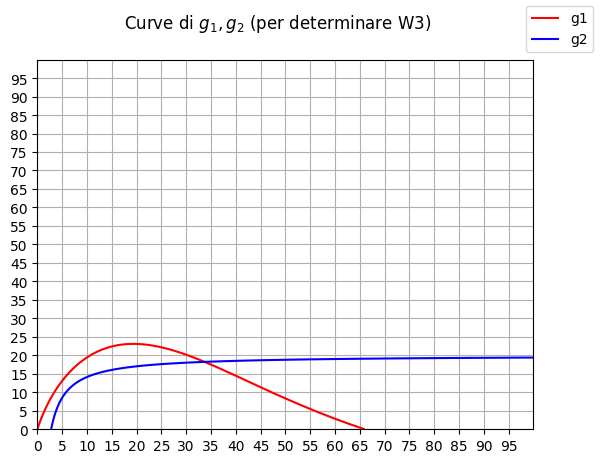

W2 (coesistenza positiva): x=33.70503694844591, y=18.230236966012498
	LAS: No
	GAS: No


In [3]:
# 0: caso in cui W2 è GAS... apparentemente

parameters = {
    'r': 2,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.03,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.02,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
}

for i, data_0 in enumerate([(8,2), (2, 3), (8, 5), (5, 7), (15, 10)]):
    x, y = data_0
    simulate(x, y, 50, **parameters, name=f"0_{i}")

check_stability(**parameters)

W0 (estinzione): x=0, y=0
	LAS: No
	GAS: No
W1 (assenza di predatori): x=66.0, y=0
	LAS: No
	GAS: Yes


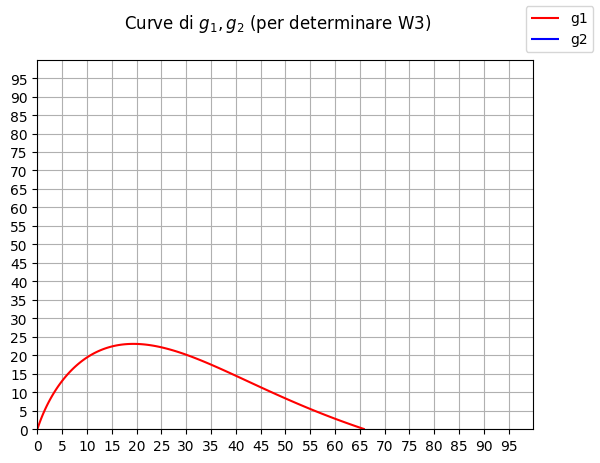

Punto d'equilibrio di coesistenza non esiste (soluzione trovata ha componente negativa)
N.B. Il punto d'equilibrio potrebbe esistere nonostante ciò, si consiglia di considerare a riutilizzare la funzione sfruttando il grafico prodotto sopra e inserendo in configurazione il punto iniziale del solver.


In [81]:
# 1: caso in cui W1 è globalmente attrattivo
parameters = {
    'r': 2,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.03,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.02,
    'd': 0.2,
    'sigma': 0.5,
    'psi': 0.01,
}

initial_points = [(2, 3), (10, 2), (8, 5), (7,7), (15, 12)]

for i, data_0 in enumerate(initial_points):
    x, y = data_0
    simulate(x, y, 100, **parameters, name=f"1_{i}")

check_stability(**parameters)

W0 (estinzione): x=0, y=0
	LAS: Yes
	GAS: No
W2 non esiste


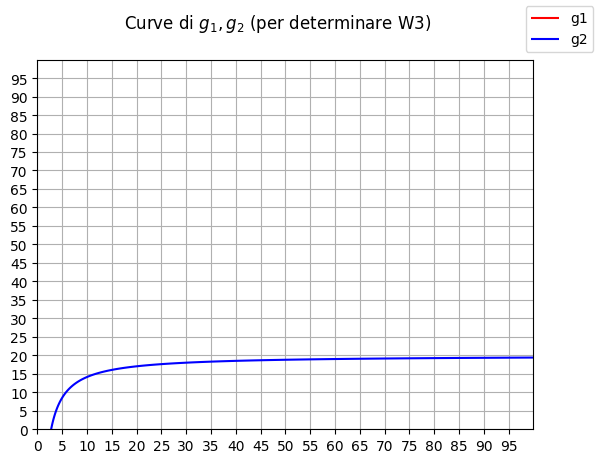

Punto d'equilibrio di coesistenza non esiste (soluzione trovata ha componente negativa)
N.B. Il punto d'equilibrio potrebbe esistere nonostante ciò, si consiglia di considerare a riutilizzare la funzione sfruttando il grafico prodotto sopra e inserendo in configurazione il punto iniziale del solver.


In [82]:
# 2: caso in cui W0 è globalmnte attrattivo
parameters = {
    'r': 0.002,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.03,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.02,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
}

initial_points = [(2, 3), (10, 2), (8, 5), (7,7), (15, 12)]

check_stability(**parameters)

for i, data_0 in enumerate(initial_points):
    x, y = data_0
    simulate(x, y, 15, **parameters, name=f"2_{i}")

In [83]:
# 3: soluzioni periodiche

params_1 = {
    'r' : 1.2,
    'f' : 0.03,
    'a' : 0.02,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
    'solver': 'RK45'

}

params_2 = {
    'r': 2,
    'f': 0.5,
    'a': 0.02,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
    'solver': 'RK45'
}

params_3 = {
    'r': 2,
    'f': 0.03,
    'a': 0.4,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
    'solver': 'RK45'

}

simulate(5, 7, 1500, **params_1, name="3_0")
simulate(5, 7, 1500, **params_2, name="3_1")
simulate(5, 7, 1500, **params_3, name="3_2")


In [84]:
# 4. modificare k, epsilon
parameters = {
    'r': 2,
    'beta': 0.5,
    'e': 0.4,
    'f': 0.03,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.02,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
}

simulate(5, 7, 100, **parameters, k=0.03, eps=0.01, name="4_0")
simulate(5, 7, 100, **parameters, k=0.0003, eps = 0.01, name="4_1")
simulate(5, 7, 1500, **parameters, k=0.03, eps=0.001, name="4_2")


In [85]:
# 5: modificare e

parameters = {
    'r': 2,
    'beta': 0.5,
    'm': 0.1,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.03,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.02,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
}



for i, e_ in enumerate([0.005, 0.4, 0.7]):
    simulate(5, 7, 500, **parameters, e=e_, name=f"5_{i}")

In [86]:
# 6: modificare m

parameters = {
    'r': 2,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.03,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.02,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
}

for i, m_ in enumerate([0.1, 0.25, 0.9]):
    simulate(5, 7, 80, **parameters, m=m_, name=f"6_{i}")

### Grafici
Proponiamo i risultati disegnando i grafichetti

In [119]:
def create_graphs(number: int, mult: int, add: int = 0, return_mode = False):
    # creo grafici di un esperimento
    # number: numero dell'esperimento
    # mult: di solito gli esperimenti coinvolgono più simulazioni simultanee, quindi dire quanti sono le simulazioni...
    # add: serve solo se voglio prendere una parte specifica dell'esperimento
    
    data = []

    # carico dati salvati in file
    for i in range(mult):
        try:
            data.append(np.loadtxt(f"./data/{number}_{i}.csv", delimiter=','))
        except:
            raise Exception("Parametri in configurazione invalidi!!!")

    # definisco colori
    markers = ['r', 'g', 'b', 'y', 'k', 'c', 'm']

    # canvas
    fig, axes = plt.subplots(1, 2, figsize = (14, 6))
    fig.suptitle(f"Experiment {number}")

    ax1 = axes[0]
    ax2 = axes[1]

    # primo plot: time series
    for i in range(add, mult):
        ax1.plot(data[i][ :, 0], data[i][ :, 1], markers[i])
        ax1.plot(data[i][ :, 0], data[i][ :, 2], f"{markers[i]}--")

    ax1.set_title(f'Time Series\n(N.B. Linee continue = prede, Linee tratteggiate = predatori)')
    ax1.set_xlabel('t')
    ax1.set_ylabel('size')
    ax1.grid()

    # secondo plot: fasi
    for i in range(add, mult):
        ax2.plot(data[i][ :, 1], data[i][ :, 2], markers[i])

    ax2.set_title(f'Phase Diagram')
    ax2.set_xlabel('preys')
    ax2.set_ylabel('predators')
    ax2.grid()

    # show!
    if not return_mode:
        plt.show()

    return fig, axes

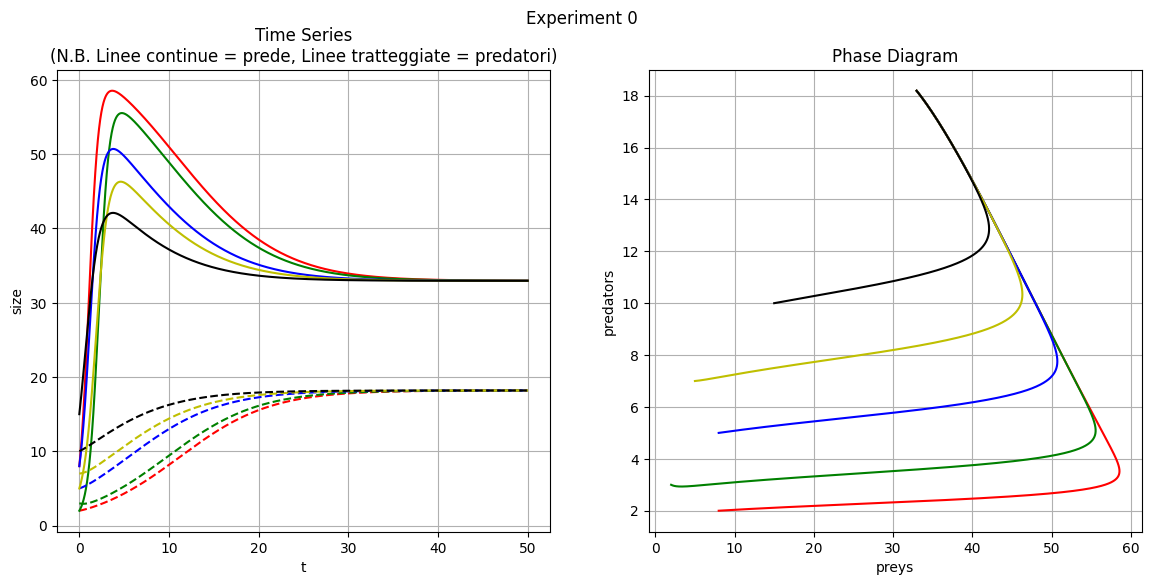

(<Figure size 1400x600 with 2 Axes>,
 array([<Axes: title={'center': 'Time Series\n(N.B. Linee continue = prede, Linee tratteggiate = predatori)'}, xlabel='t', ylabel='size'>,
        <Axes: title={'center': 'Phase Diagram'}, xlabel='preys', ylabel='predators'>],
       dtype=object))

In [88]:
create_graphs(0, 5)

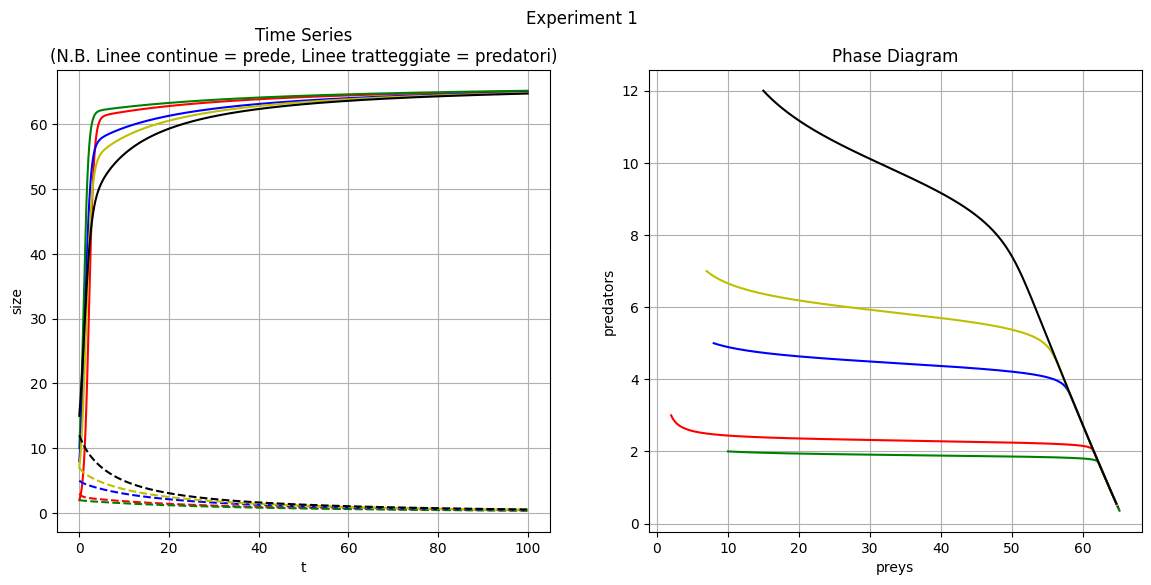

(<Figure size 1400x600 with 2 Axes>,
 array([<Axes: title={'center': 'Time Series\n(N.B. Linee continue = prede, Linee tratteggiate = predatori)'}, xlabel='t', ylabel='size'>,
        <Axes: title={'center': 'Phase Diagram'}, xlabel='preys', ylabel='predators'>],
       dtype=object))

In [89]:
create_graphs(1, 5)

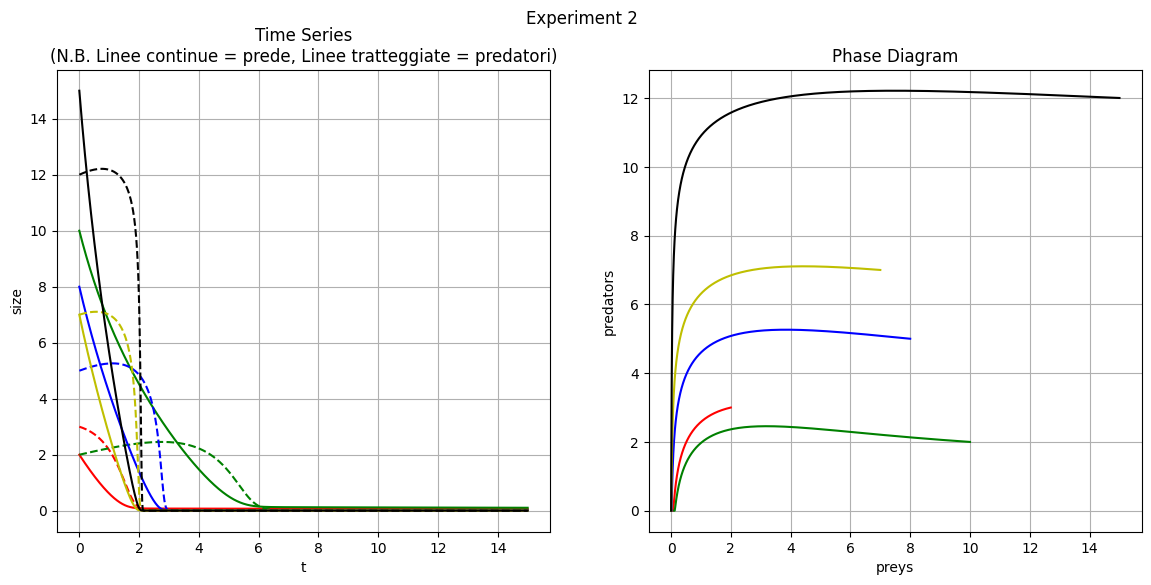

(<Figure size 1400x600 with 2 Axes>,
 array([<Axes: title={'center': 'Time Series\n(N.B. Linee continue = prede, Linee tratteggiate = predatori)'}, xlabel='t', ylabel='size'>,
        <Axes: title={'center': 'Phase Diagram'}, xlabel='preys', ylabel='predators'>],
       dtype=object))

In [90]:
create_graphs(2,5)

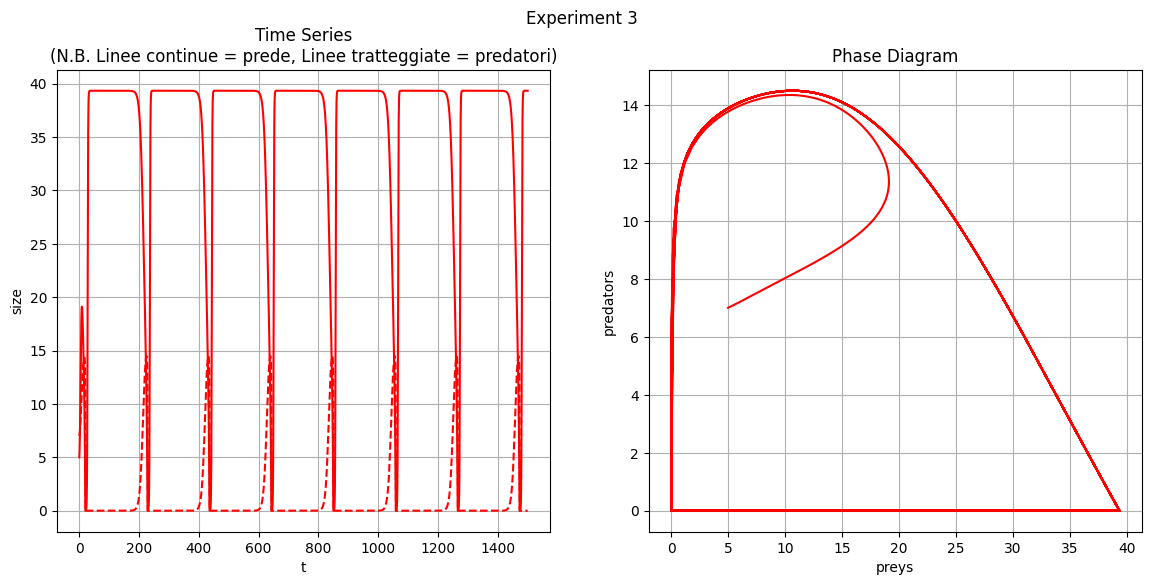

(<Figure size 1400x600 with 2 Axes>,
 array([<Axes: title={'center': 'Time Series\n(N.B. Linee continue = prede, Linee tratteggiate = predatori)'}, xlabel='t', ylabel='size'>,
        <Axes: title={'center': 'Phase Diagram'}, xlabel='preys', ylabel='predators'>],
       dtype=object))

In [91]:
create_graphs(3, 1)

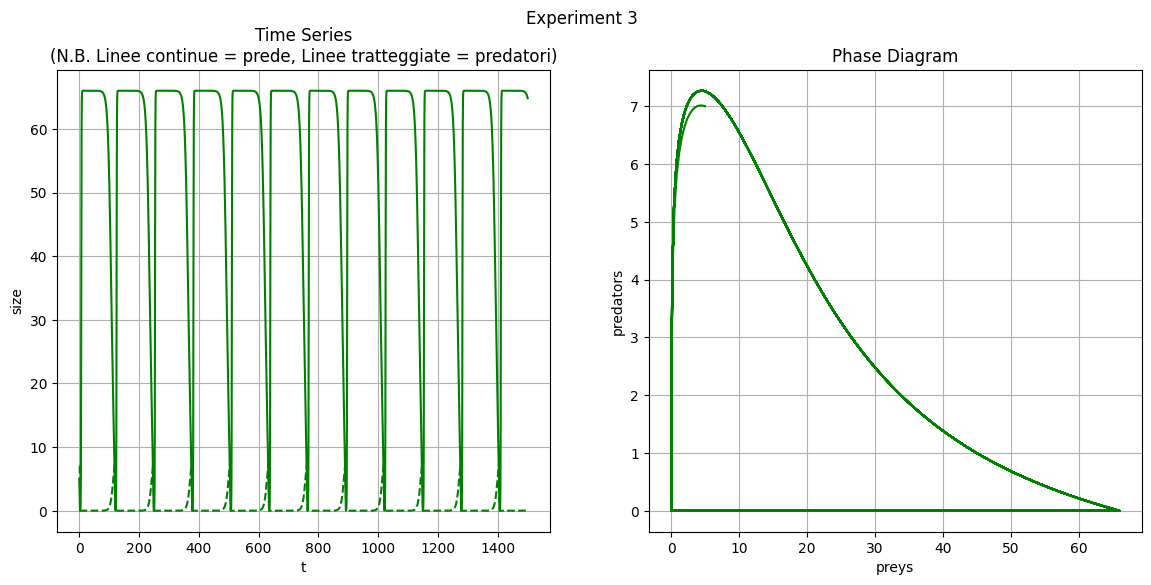

(<Figure size 1400x600 with 2 Axes>,
 array([<Axes: title={'center': 'Time Series\n(N.B. Linee continue = prede, Linee tratteggiate = predatori)'}, xlabel='t', ylabel='size'>,
        <Axes: title={'center': 'Phase Diagram'}, xlabel='preys', ylabel='predators'>],
       dtype=object))

In [92]:
create_graphs(3, 2, 1)

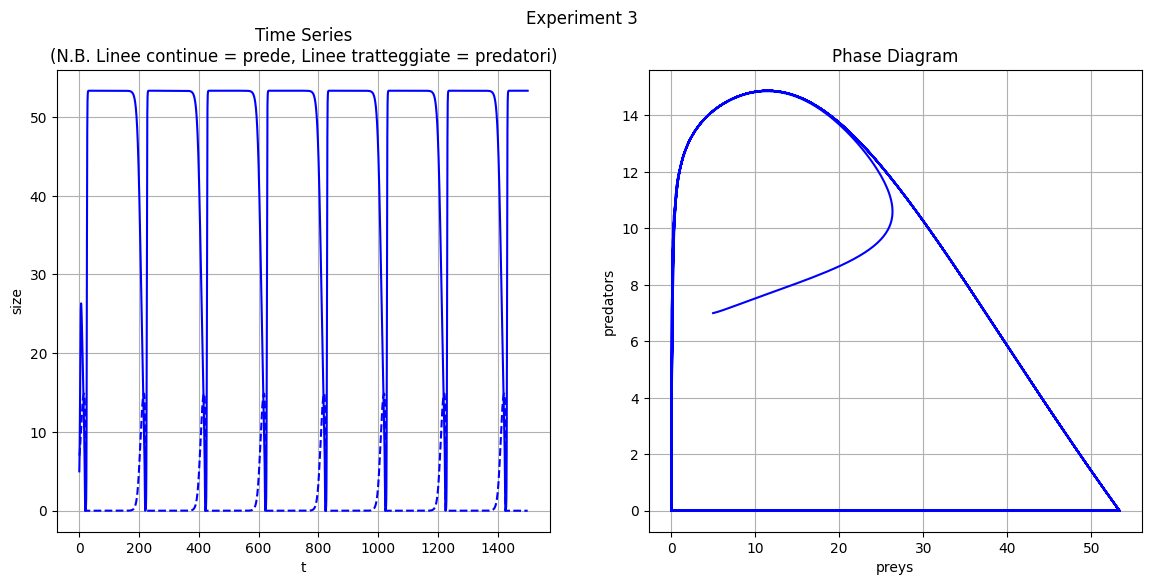

(<Figure size 1400x600 with 2 Axes>,
 array([<Axes: title={'center': 'Time Series\n(N.B. Linee continue = prede, Linee tratteggiate = predatori)'}, xlabel='t', ylabel='size'>,
        <Axes: title={'center': 'Phase Diagram'}, xlabel='preys', ylabel='predators'>],
       dtype=object))

In [93]:
create_graphs(3, 3, 2)

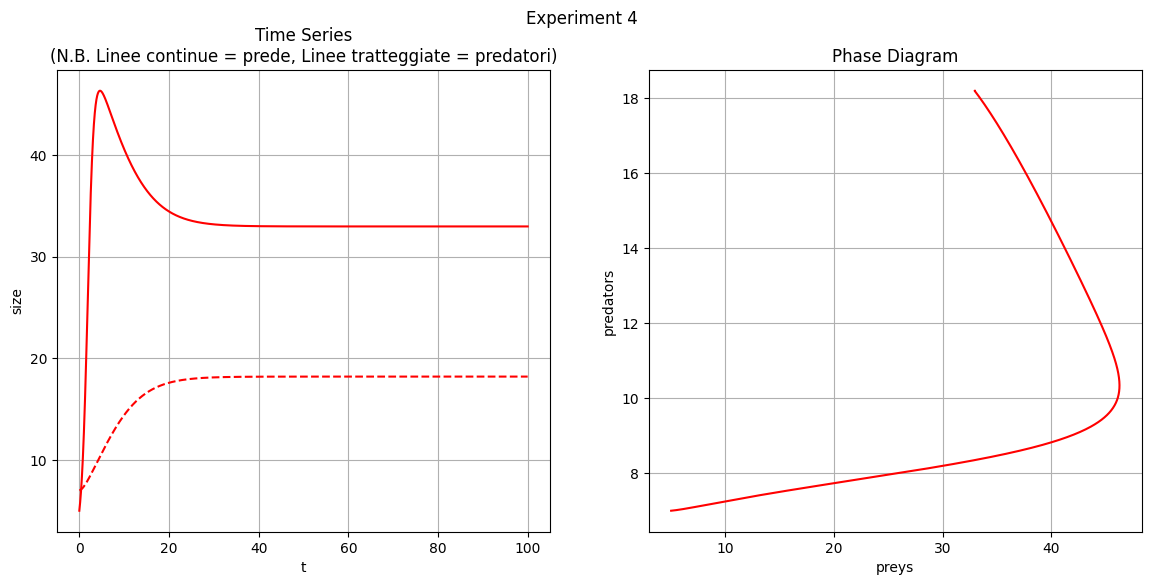

(<Figure size 1400x600 with 2 Axes>,
 array([<Axes: title={'center': 'Time Series\n(N.B. Linee continue = prede, Linee tratteggiate = predatori)'}, xlabel='t', ylabel='size'>,
        <Axes: title={'center': 'Phase Diagram'}, xlabel='preys', ylabel='predators'>],
       dtype=object))

In [94]:
create_graphs(4, 1)

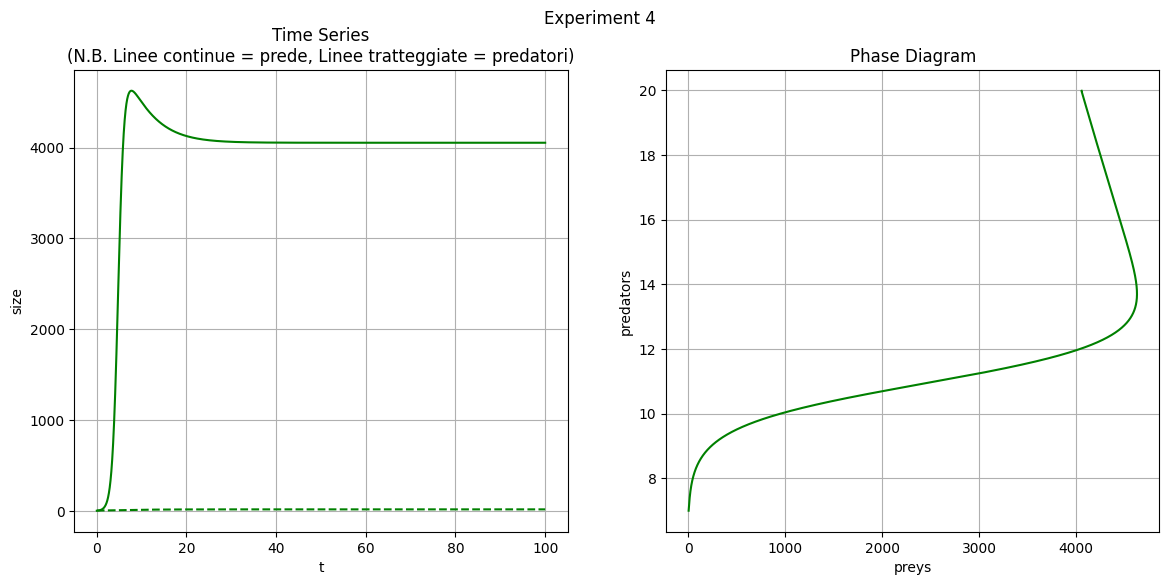

(<Figure size 1400x600 with 2 Axes>,
 array([<Axes: title={'center': 'Time Series\n(N.B. Linee continue = prede, Linee tratteggiate = predatori)'}, xlabel='t', ylabel='size'>,
        <Axes: title={'center': 'Phase Diagram'}, xlabel='preys', ylabel='predators'>],
       dtype=object))

In [95]:
create_graphs(4, 2, 1)

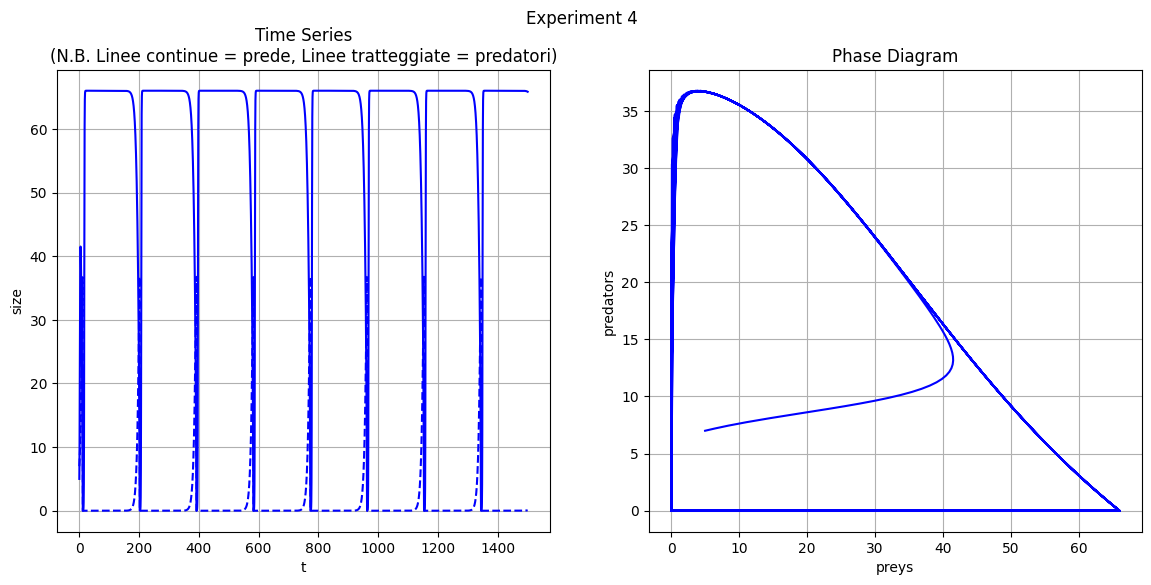

(<Figure size 1400x600 with 2 Axes>,
 array([<Axes: title={'center': 'Time Series\n(N.B. Linee continue = prede, Linee tratteggiate = predatori)'}, xlabel='t', ylabel='size'>,
        <Axes: title={'center': 'Phase Diagram'}, xlabel='preys', ylabel='predators'>],
       dtype=object))

In [96]:
create_graphs(4, 3, 2)

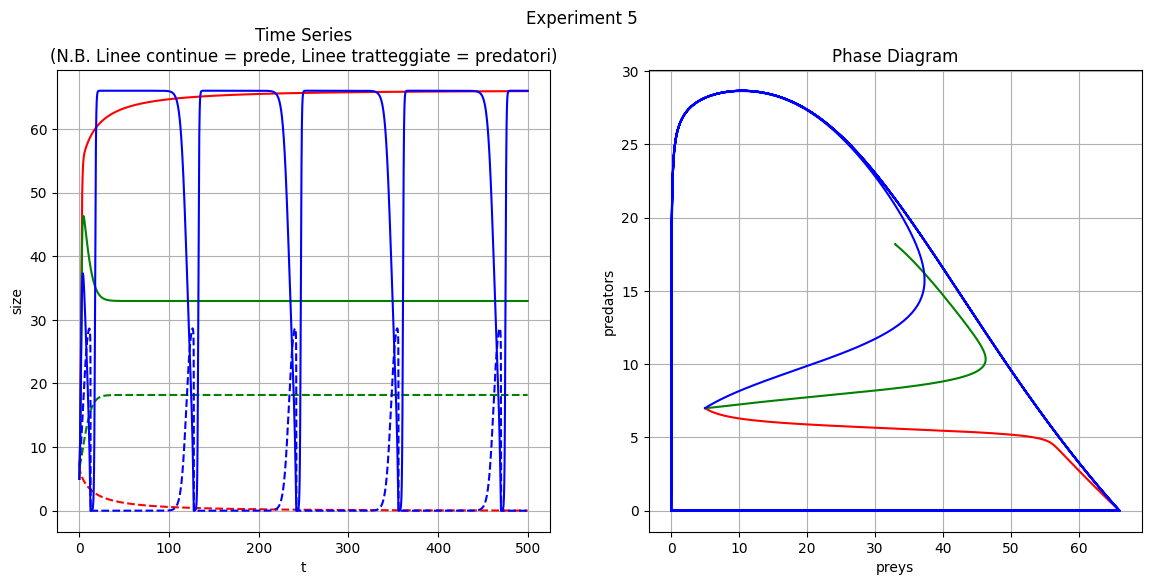

(<Figure size 1400x600 with 2 Axes>,
 array([<Axes: title={'center': 'Time Series\n(N.B. Linee continue = prede, Linee tratteggiate = predatori)'}, xlabel='t', ylabel='size'>,
        <Axes: title={'center': 'Phase Diagram'}, xlabel='preys', ylabel='predators'>],
       dtype=object))

In [97]:
create_graphs(5, 3)

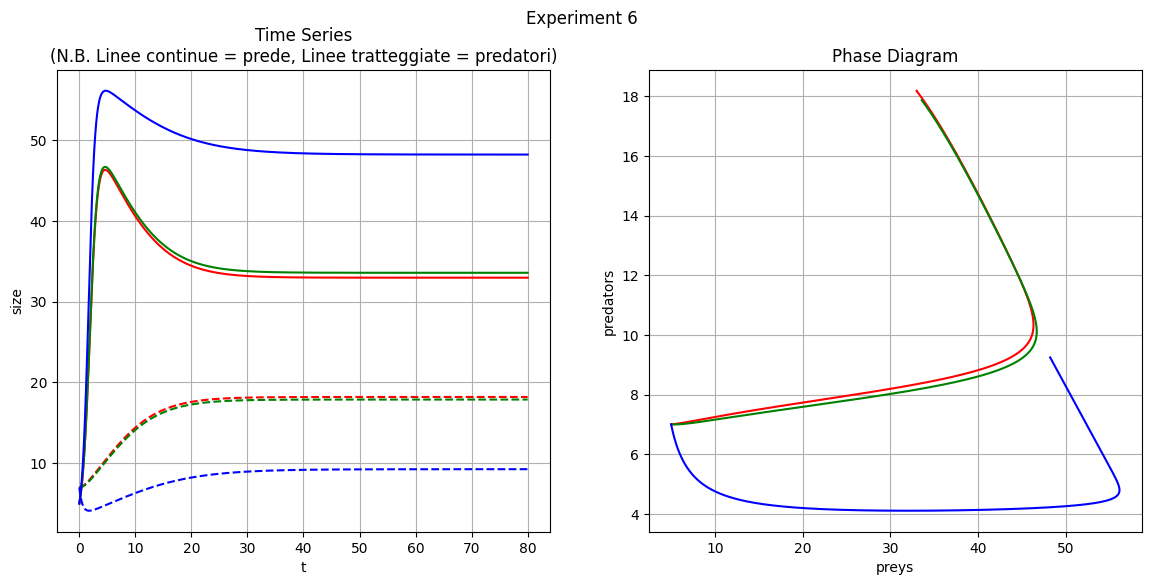

(<Figure size 1400x600 with 2 Axes>,
 array([<Axes: title={'center': 'Time Series\n(N.B. Linee continue = prede, Linee tratteggiate = predatori)'}, xlabel='t', ylabel='size'>,
        <Axes: title={'center': 'Phase Diagram'}, xlabel='preys', ylabel='predators'>],
       dtype=object))

In [98]:
create_graphs(6, 3)

### Animazioni
Aggiuntivamente, ho creato alcune animazioni per dare un'idea migliore delle simulazioni (anche per flexare)

In [232]:
# animate time diagram
# animate the phase diagram

def animate_plots(number: int, mult: int, add: int = 0, multiplier: int = 30):
    # creo grafici di un esperimento
    # number: numero dell'esperimento
    # mult: di solito gli esperimenti coinvolgono più simulazioni simultanee, quindi dire quanti sono le simulazioni...
    # add: serve solo se voglio prendere una parte specifica dell'esperimento
    # multiplier: serve per rendere il rendering più veloce, ossia skippare alcuni dati (sennò il mio pc ci mette decenni...)
    
    data = []

    # carico dati salvati in file
    for i in range(mult):
        try:
            data.append(np.loadtxt(f"./data/{number}_{i}.csv", delimiter=','))
        except:
            raise Exception("Parametri in configurazione invalidi!!!")
            

    data = np.array(data)

    fig, axes = plt.subplots(1, 2, figsize=(14,6))
    fig.suptitle(f"Experiment {number}")


    # time series
    ax1 = axes[0]
    ax2 = axes[1]

    prey_curves = []
    predator_curves = []

    markers = ['r', 'b', 'y', 'g', 'k']

    for i in range(add, mult):
        prey_curves.append(ax1.plot(data[i][0, 0], data[i][0, 1], markers[i]))
        predator_curves.append(ax1.plot(data[i][0, 0], data[i][0, 2], f"{markers[i]}--"))

    ax1.set_title(f"Time Series")
    ax1.grid()
    ax1.set_xlabel("t")
    ax1.set_ylabel("amount")

    ax1.set_xlim(0, data[0, -1, 0] - 1)
    ax1.set_ylim(np.min(data[:, :, [1,2]]) - 2, np.max(data[:, :, [1,2]]) + 2)

    phase_curves = []
    phase_dots = []

    dots = ['ro', 'bo', 'yo', 'go', 'ko']

    for i in range(add, mult):
        phase_curves.append(ax2.plot(data[i][0, 1], data[i][0, 2], markers[i]))
        phase_dots.append(ax2.plot(data[i][0, 1], data[i][0, 2], dots[i]))

    ax2.set_title(f"Phase Diagram")
    ax2.grid()
    ax2.set_xlabel("preys")
    ax2.set_ylabel("predators")

    ax2.set_xlim(np.min(data[:, :, [1]]) - 3, np.max(data[:, :, [1]]) + 3)
    ax2.set_ylim(np.min(data[:, :, [2]]) - 3, np.max(data[:, :, [2]]) + 3) # tutti questi -1, +1 per rendere più visibile gli estremi


    def animate(j):
        for i in range(mult-add):
            prey = prey_curves[i][0]
            predator = predator_curves[i][0]

            prey.set_data(data[i][:j*multiplier, 0], data[i][:j*multiplier, 1])
            predator.set_data(data[i][:j*multiplier, 0], data[i][:j*multiplier, 2])

        for i in range(mult-add):
            phase_curve = phase_curves[i][0]
            phase_dot = phase_dots[i][0]

            phase_curve.set_data(data[i][:j*multiplier, 1], data[i][:j*multiplier, 2])
            phase_dot.set_data([data[i][j*multiplier, 1]], [data[i][j*multiplier, 2]])

        return fig

    ani = animation.FuncAnimation(fig, animate, frames=len(data[i][:, 0])//multiplier)
    ffmpeg_writer = animation.FFMpegWriter(fps=30)
    ani.save(f'./videos/{number}_{add}.mp4', writer=ffmpeg_writer)

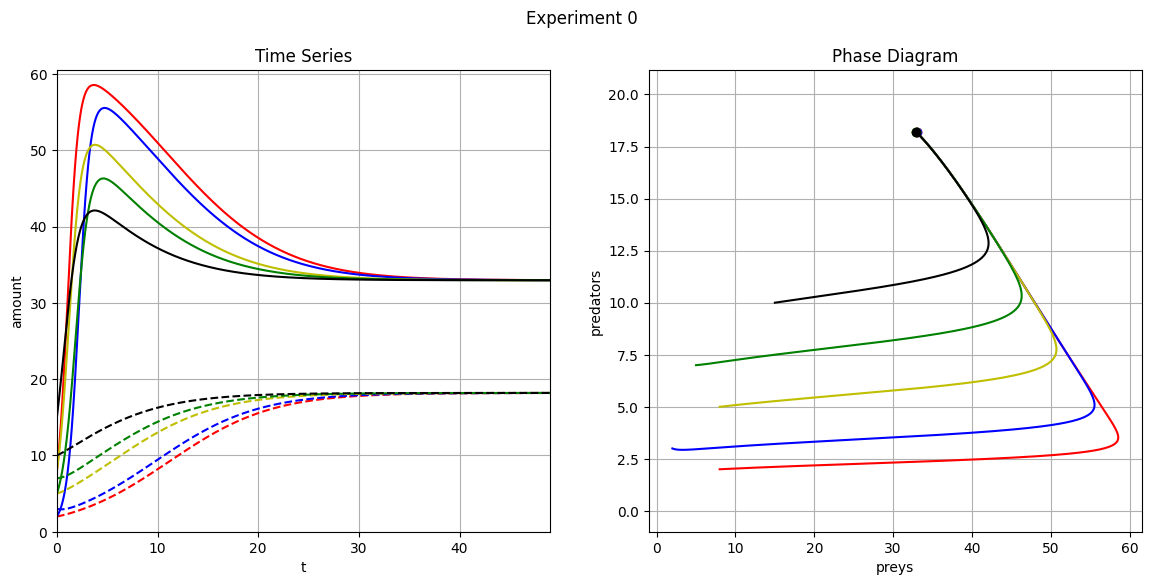

In [136]:
animate_plots(0, 5, 0, 30)

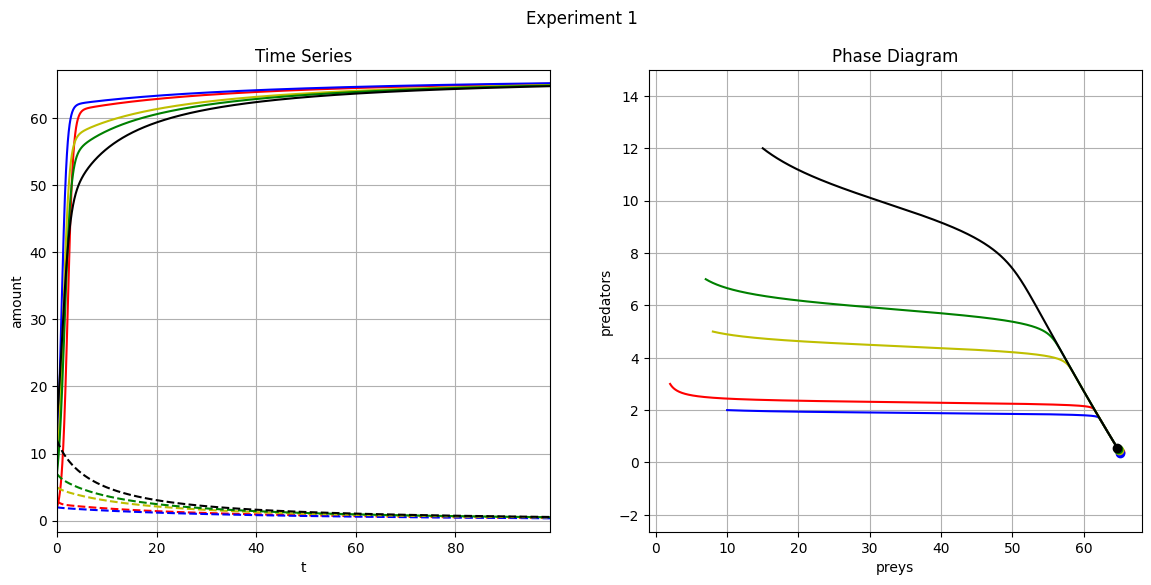

In [137]:
animate_plots(1, 5, 0, 30)

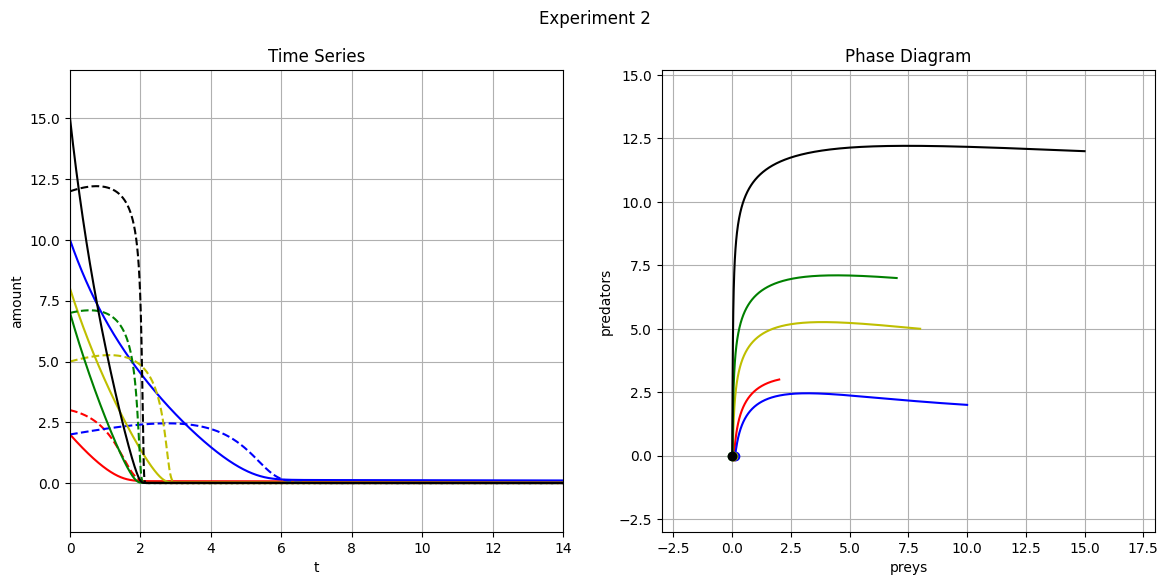

In [138]:
animate_plots(2, 5, 0, 30)

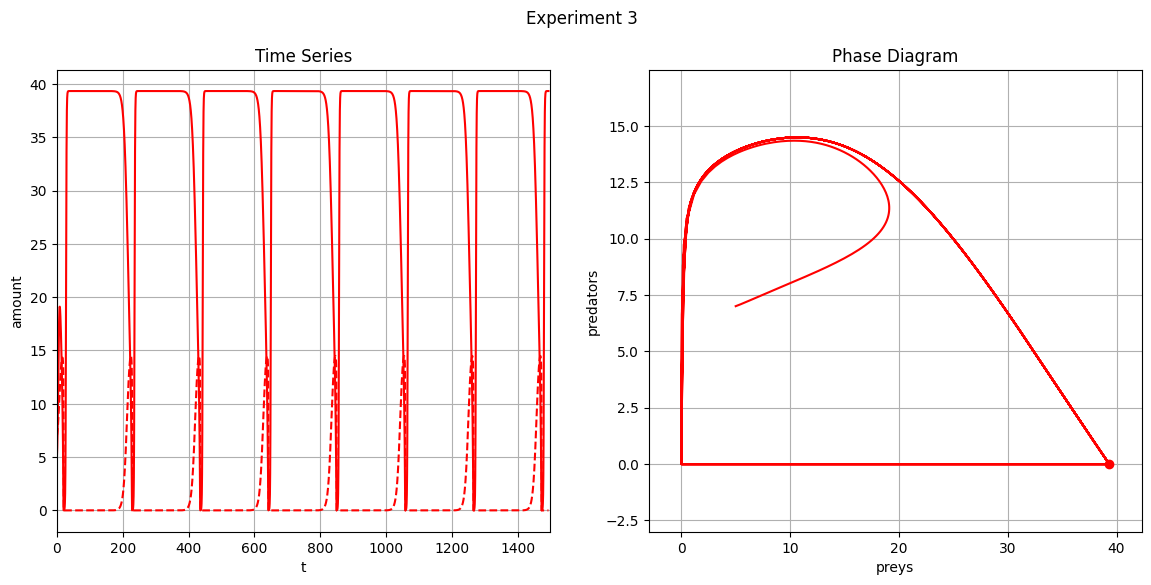

In [139]:
animate_plots(3, 1, 0, 30)

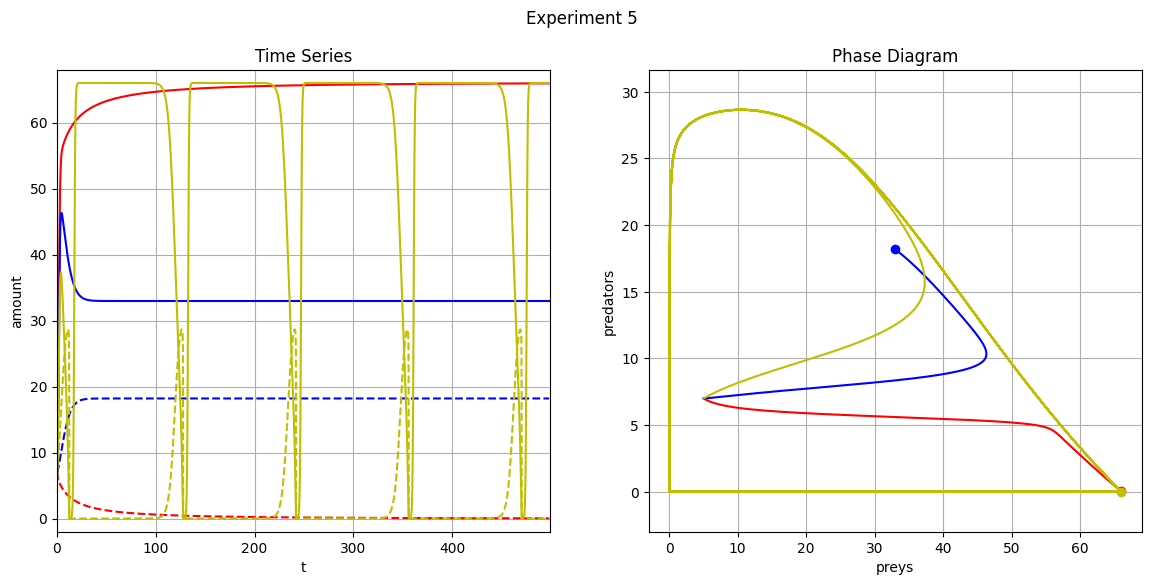

In [140]:
animate_plots(5, 3, 0, 30)

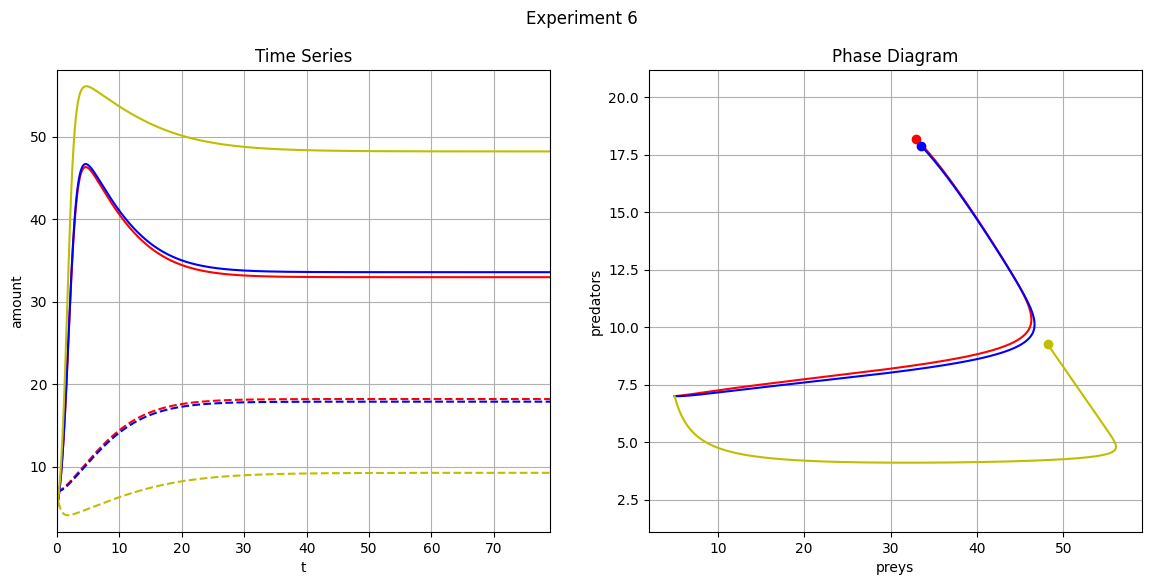

In [141]:
animate_plots(6, 3, 0, 30)

## Parte 3: Differenze con risultati proposti nel paper
Sono stati dei riscontrati dei problemi di riproducibilità col paper proposto, in particolare in alcune differenze tra risultati proposti nel paper e risultati prodotti (in alcuni casi specifici)

### Non replicabilità dei risultati: Alcuni Punti d'Equilibrio

**Esperimento 0.** Nel replicare la prima figura, è stata rilevata un'inconsistenza tra il punto d'equilibrio W2 calcolato con gli isoclini forniti del paper e i risultati dell'esperimento (*fig. 1*), infatti:

- Il risolutore ha trovato x=33.70503694844591, y=18.230236966012498 come punto d'equilibrio
- In realtà negli esperimenti i punti convergono verso x = 32.972771274944044, y=18.184219824294573

Ciò contraddice inoltre quanto viene riportato nel paper, infatti viene riportato il punbto d'equilibrio $W_2 = (33,18)$, di cui si presume un'approssimazione di $(x = 32.972771274944044, y=18.184219824294573)$.

Si deduce che le isocline siano *"leggermente"* scorrette, nella sezione successiva si proporrà un'implementazione alternativa e più semplice.

W0 (estinzione): x=0, y=0
	LAS: No
	GAS: No
W1 (assenza di predatori): x=66.0, y=0
	LAS: No
	GAS: Yes


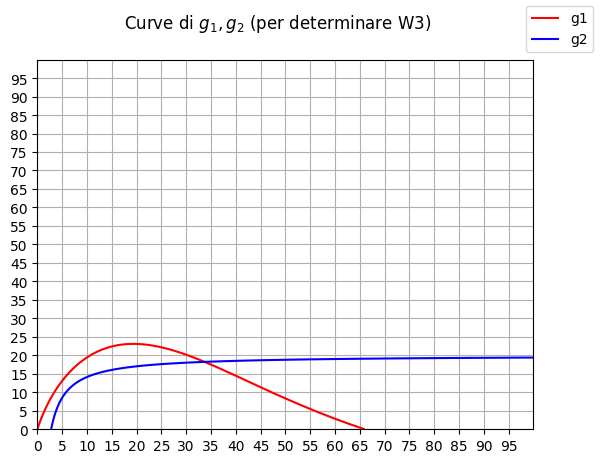

W2 (coesistenza positiva): x=33.70503694844591, y=18.230236966012498
	LAS: No
	GAS: No


In [5]:
parameters = {
    'r': 2,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.03,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.02,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
}

check_stability(**parameters)

In [102]:
data = np.loadtxt(r"./data/0_0.csv", delimiter=",")

x = data[-1, [1,2]][0]
y = data[-1, [1,2]][1]

print("x = {}, y={}".format(x,y))

x = 32.972771274944044, y=18.184219824294573


**Esperimento 4.** L'esperimento 4, che tentava di riprodurre la *figura 9*, ha riscontrato un'altra inconsistenza con i risultati enunciati nell'articolo. In particolare, inserendo $k=0.0003$, sono stati ottenuti i seguenti risultati:

- Esiste un punto d'equilibrio di coesistenza in circa $(4000, 20)$ ed è globalmente attrattiva 
- Il punto d'equilibrio di assenza degli predatori è in $(6600, 0)$

Invece nel paper è stato proposto che con questa configurazione il modello converge al punto d'equilibrio di assenza degli predatori in $(2.6, 0)$. Tuttavia ciò è impossibile con la configurazione proposta, in quanto $W_1 = (r-a)/k$ e quindi dev'essere per forza un "numero molto grande" per $k$ "molto piccolo".

W0 (estinzione): x=0, y=0
	LAS: No
	GAS: No
W1 (assenza di predatori): x=6600.000000000001, y=0
	LAS: No
	GAS: Yes


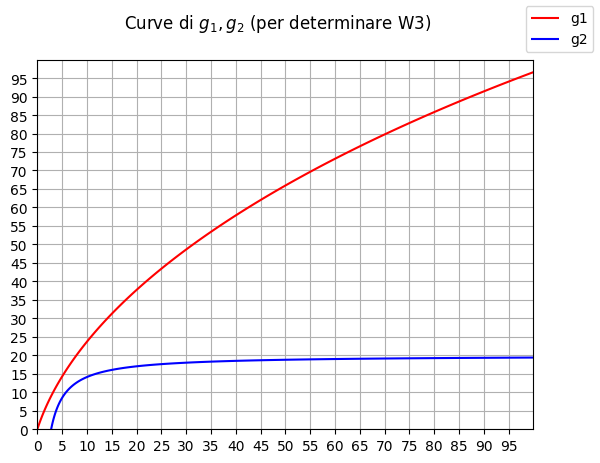

W2 (coesistenza positiva): x=4118.194850372055, y=19.983431461993533
	LAS: No
	GAS: No


In [103]:
parameters = {
    'r': 2,
    'beta': 0.5,
    'e': 0.4,
    'f': 0.03,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.02,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
}

check_stability(**parameters, k=0.0003, eps=0.01, init_solver=(4000, 20))

### Non replicabilità dei risultati: Cicli Limite
L'esperimento *3* tentava di riprodurre le *figure 6, 7, 8* che sono dei casi in cui il modello converge ad un *ciclo limite*. 

I risultati confermano che in effetti c'è il ciclo limite, tuttavia i cicli limite proposto nel paper sono diversi da quelli prodotti nelle simulazioni.

Vedere la figura sotto per un esempio di confronto, di due simulazioni eseguite con la stessa configurazione (presumibilmente):

![](./figures/image.png)


### Non replicabilità dei risultati: Test per determinare stabilità dei punti d'equilibrio

Nel progetto ho tentato di implementare delle funzioni *test* per controllare la stabilità di eventuali punti di equilibrio, direttamente dagli enunciati dei teoremi.

Tuttavia, ciò non è stato efficace a determinare in effetti la stabilità dei punti d'equilibrio; infatti, alcuni punti d'equilibrio erano stabili ma il test diceva che non lo erano e viceversa.

Inoltre alcuni test sono, da un punto di vista matematico, dubbiosi: ad esempio il teorema 4.5. enuncia che il punto d'equilibrio PFEP (assenza di predatori) è GAS per $x_E>1$ e $\psi > (1-m)(1-x_E)$. Tuttavia, ciò implica che ogni PFEP è GAS in quanto se $x_E > 1$ allora $(1-x_E)<0$ e quindi essendo $\psi$ un coefficiente positivo, dev'essere vero anche $\psi > (1-m)(1-x_E)$ (in quanto $<0m<1$ essendo anch un "rate").

## Parte 4: Ulteriori sperimentazioni

### Correzione dell'algoritmo per trovare il punto d'equilibrio di coesistenza

Per correggere l'algoritmo che trova i punti d'equilibrio (in particolare quello di coesistenza), abbiamo modificato la definizione degli isoclini in un modo tale da riflettere la definizione del modello in maniera più accurata. In questo caso, è stato sufficiente prendere la definizione del modello e togliere il fattore $x$ (o $y$).

In [8]:

def find_PIEP(r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma, psi, init_solver = (50,50), silent=False): 
    # W2: PIEP
    def g1(vec):
        x, y = vec
        return (r / (1+f*y)) - ((beta * (1-m) * y)/(psi*y + alpha*theta + (1-m)*x)) - a * (1+f*y) - k*x

    def g2(vec):
        x,y = vec
        return ((e * beta * (1-m)*x)/(psi*y + alpha*theta + (1-m)*x)) - d - (sigma / ((1-m)*x + alpha*theta)) - eps*y
    

    ## curve g1=0, g2=0 per aiutare l'user a determinare una sua intersezione approssimativa (così da aiutare il solver...)
    if not silent:
        delta = 0.025
        xrange = np.arange(0, 100, delta)
        yrange = np.arange(0, 100, delta)

        X, Y = np.meshgrid(xrange, yrange)


        fig, ax = plt.subplots()

        fig.suptitle("Curve di $g_1, g_2$ (per determinare W3)")
        ax.grid(True)
        ax.set_xticks(np.arange(0, 100, 5))
        ax.set_yticks(np.arange(0, 100, 5))

        cs1 = ax.contour(X, Y, g1([X, Y]), [0], colors='r')
        cs2= ax.contour(X, Y, g2([X, Y]), [0], colors='b')

        artists1, _ = cs1.legend_elements()
        artists2, _ = cs2.legend_elements()


        fig.legend(artists1 + artists2, ['g1', 'g2'])
        
        plt.show()
    
    sol = fsolve(lambda vec: (g1(vec), g2(vec)), init_solver)

    x2, y2 = sol
    

    if x2 < 0 or y2 < 0:
        if not silent:
            print("Punto d'equilibrio di coesistenza non esiste (soluzione trovata ha componente negativa)")
            print("N.B. Il punto d'equilibrio potrebbe esistere nonostante ciò, si consiglia di considerare a riutilizzare la funzione sfruttando il grafico prodotto sopra e inserendo in configurazione il punto iniziale del solver.")
        return -1

    else:
        if not silent:
            print(f"W2 (coesistenza positiva): x={x2}, y={y2}")

        return x2, y2


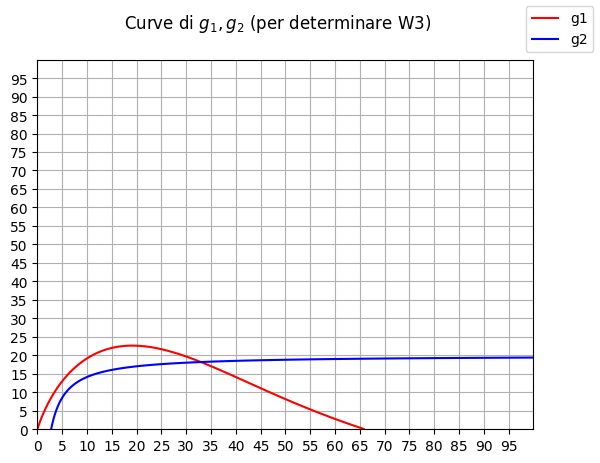

W2 (coesistenza positiva): x=32.95651821324798, y=18.190369110171137


(32.95651821324798, 18.190369110171137)

In [10]:
parameters = {
    'r': 2,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.03,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.02,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
}

find_PIEP(**parameters)

Ciò è coerente con i risultati sperimentali visti, infatti siamo più vicini ai dati ottenuti.

### Determinazione della Stabilità Alternativa
Implementiamo un algoritmo alternativo per determinare la stabilità locale dei punti. In particolare invece di usufruire in maniera diretta i risultati dimostrati del paper, andremo a calcolare direttamente la Jacobiana del sistema.


In [6]:

def jac(W, r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma, psi):

    x, y = W

    T1 = beta * (1-m) * (psi*y + alpha*theta) * y 
    T2 = beta * (1-m) * (alpha*theta + (1-m)*x)
    Tast = (psi*y + alpha*theta + (1-m)*x)**2


    J = np.zeros((2,2))

    J[0,0] = r/(1+f*y) - T1/Tast - a*(1+f*y) - 2*k*x
    J[0,1] = (-r * f * x)/( (1+f*y)**2 ) - x * (T2/Tast) - a*f*x
    J[1,0] = e*(T1/Tast) - (sigma*(1-m)*y) / ( ((1-m)*x + alpha*theta)**2 )
    J[1,1] = e*x*(T2/Tast) - d - eps - sigma/(((1-m)*x + alpha*theta)**2)

    return J

def check_stability_alt(r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma, psi, init_solver=(50,50)):
    W1 = (0,0)
    W2 = ((r-a)/k, 0) 
    W3 = find_PIEP(r, beta, e, k, eps, f, m , alpha, theta, a, d, sigma, psi, init_solver)

    eigv_1 = np.linalg.eigvals(jac(W1, r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma, psi))
    LAS_W1 = np.all(np.real(eigv_1) < 0)

    eigv_2 = np.linalg.eigvals(jac(W2, r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma, psi)) if r>a else None
    LAS_W2 = (np.real(eigv_2) < 0).all() if eigv_2 is not None else None 

    eigv_3 = np.linalg.eigvals(jac(W3, r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma, psi)) if W3 != -1 else None
    LAS_W3 = (np.real(eigv_3) < 0).all() if eigv_3 is not None else None

    print(f"W1: {W1}")
    print(f"\tLAS: {LAS_W1}")

    if eigv_2 is not None:
        print(f"W2: {W2}")
        print(f"\tLAS: {LAS_W2}")

    else:
        print("W2 non esiste")

    if eigv_3 is not None:
        print(f"W3: {W3}")
        print(f"\tLAS: {LAS_W3}")

    else:
        print("W3 non esiste")

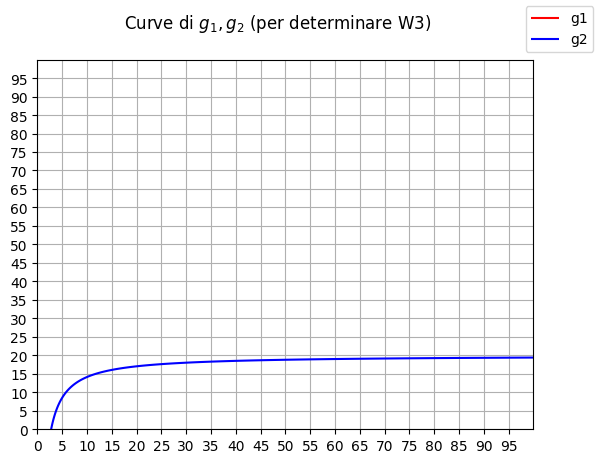

Punto d'equilibrio di coesistenza non esiste (soluzione trovata ha componente negativa)
N.B. Il punto d'equilibrio potrebbe esistere nonostante ciò, si consiglia di considerare a riutilizzare la funzione sfruttando il grafico prodotto sopra e inserendo in configurazione il punto iniziale del solver.
W1: (0, 0)
	LAS: True
W2 non esiste
W3 non esiste


C:\Users\ACER\AppData\Local\Temp\ipykernel_15448\3977527584.py:39: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  sol = fsolve(lambda vec: (g1(vec), g2(vec)), init_solver)


In [14]:
# Esempio: Caso in cui W0 è LAS
parameters = {
    'r': 0.002,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.03,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.02,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
}

check_stability_alt(**parameters)

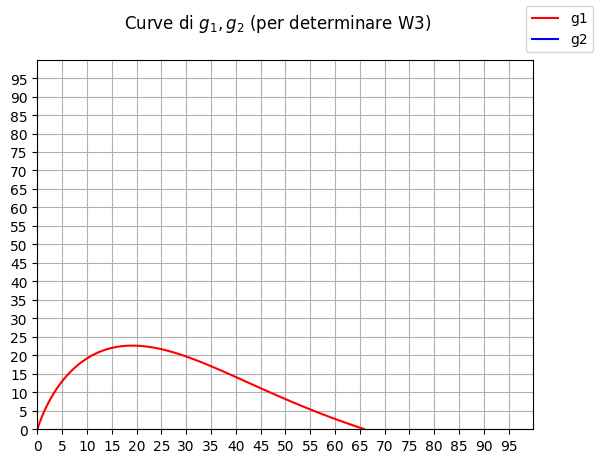

Punto d'equilibrio di coesistenza non esiste (soluzione trovata ha componente negativa)
N.B. Il punto d'equilibrio potrebbe esistere nonostante ciò, si consiglia di considerare a riutilizzare la funzione sfruttando il grafico prodotto sopra e inserendo in configurazione il punto iniziale del solver.
W1: (0, 0)
	LAS: False
W2: (66.0, 0)
	LAS: True
W3 non esiste


In [15]:
# Esempio: Caso in cui W1 è LAS
parameters = {
    'r': 2,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.03,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.02,
    'd': 0.2,
    'sigma': 0.5,
    'psi': 0.01,
}

check_stability_alt(**parameters)

### Nuovo strumento: disegno del campo vettoriale

Ho ritenuto che sarebbe stato molto utile implementare una funzione che disegni il campo vettoriale dell'ODE, ovvero effettuare un'osservazione simile a quella fatta quando abbiamo studiato i modelli di competizione.

In questo modo, sarebbe stato diventato più facile illustrare la stabilità locale/globale dei punti d'equilibrio.

In [116]:
def sub_model(x, y, r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma, psi):
    # tolte le x,y per rendere meglio la rappresentazione grafica; tanto stiamo cercando soluzioni positive...
    return (
        (r / (1+f*y)) - ((beta * (1-m) * y)/(psi*y + alpha*theta + (1-m)*x)) - a * (1+f*y) - k*x,
        ((e * beta * (1-m)*x)/(psi*y + alpha*theta + (1-m)*x)) - d - (sigma / ((1-m)*x + alpha*theta)) - eps*y
    )

def plot_vector_field(r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma, psi, xlim: Tuple[float, float], ylim: Tuple[float, float], delta: Tuple[float, float], scale: float = 1, transparency: float = 1):
    # Disegna il campo vettoriale

    xmin, xmax = xlim 
    ymin, ymax = ylim 

    deltax, deltay = delta

    x = np.arange(xmin, xmax, deltax)
    y = np.arange(ymin, ymax, deltay)
    X, Y = np.meshgrid(x, y)

    dX, dY = sub_model(X, Y, r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma, psi)

    fig, ax = plt.subplots( figsize = (15, 7.5) )

    fig.suptitle("Campo Vettoriale del modello")
    
    ax.quiver(X, Y, dX, dY, scale=scale, zorder=1, alpha=transparency)
    ax.grid(True)

    return fig, ax

def plot_vector_field_alt(r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma, psi, xlim: Tuple[float, float], ylim: Tuple[float, float], delta: Tuple[float, float], density: float = 1, transparency: float = 1):
    # Disegna il campo vettoriale in un altro modo

    xmin, xmax = xlim 
    ymin, ymax = ylim 

    deltax, deltay = delta

    x = np.arange(xmin, xmax, deltax)
    y = np.arange(ymin, ymax, deltay)
    X, Y = np.meshgrid(x, y)

    dX, dY = model(0, (X,Y), r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma, psi)

    fig, ax = plt.subplots( figsize = (15, 7.5) )

    fig.suptitle("Campo Vettoriale del modello")
    
    ax.streamplot(X, Y, dX, dY, density=density, color=(0,0,0,transparency))
    ax.grid(True)

    return fig, ax

(45.550203119323605, 18.687588533659234)


(<Figure size 1500x750 with 1 Axes>, <Axes: >)

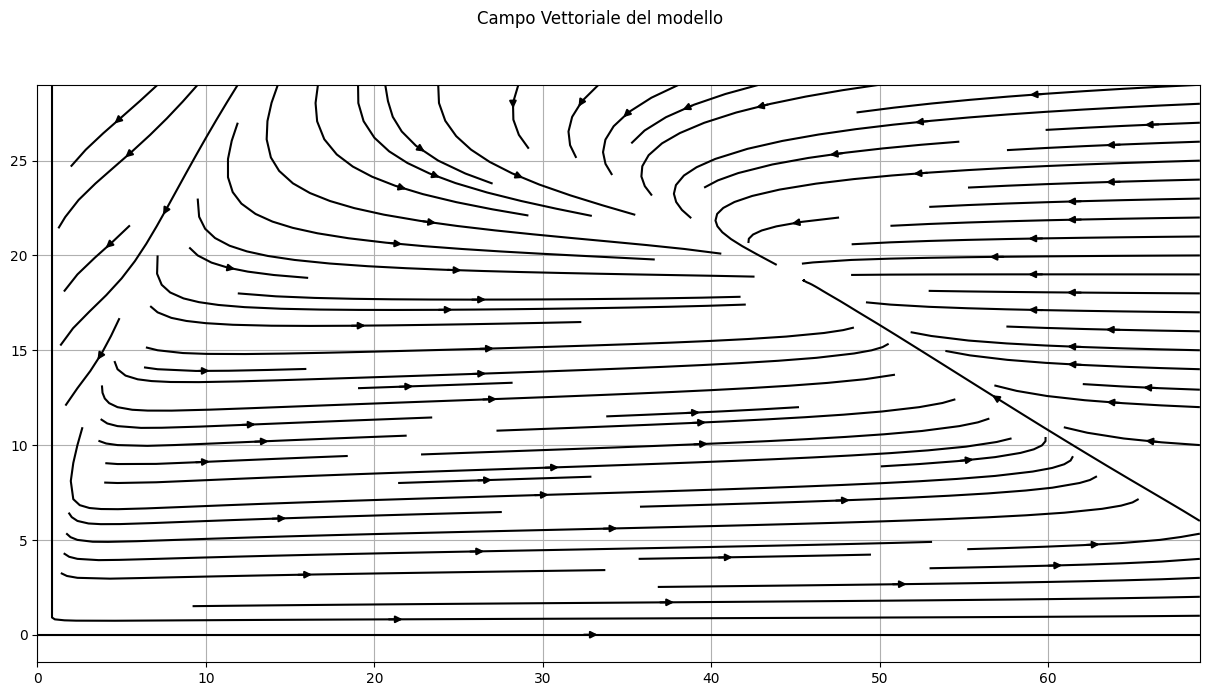

In [117]:
parameters = {
    'r': 2.5,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.03,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.02,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
}

print(find_PIEP(**parameters, silent=True))

plot_vector_field_alt(xlim = (0, 70), ylim = (0, 30), delta=(1, 1), density=1, **parameters)

Possiamo sfruttare questo tipo di grafico per rendere ancora più illustrative i grafici. Un esempio è dato come segue:

$$
\begin{gather*}
r = 2,
    \beta= 0.5,
e= 0.4,
k= 0.03,
\varepsilon= 0.01,
f= 0.5,\\
m= 0.1,
\alpha =0.00003,
\theta= 0.00002,\\
a =0.4,
d = 0.00002,
\sigma = 0.5,
\psi = 0.01,
\end{gather*}
$$

c:\Users\ACER\anaconda3\Lib\site-packages\scipy\integrate\_ivp\ivp.py:621: UserWarning: The following arguments have no effect for a chosen solver: `solver`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


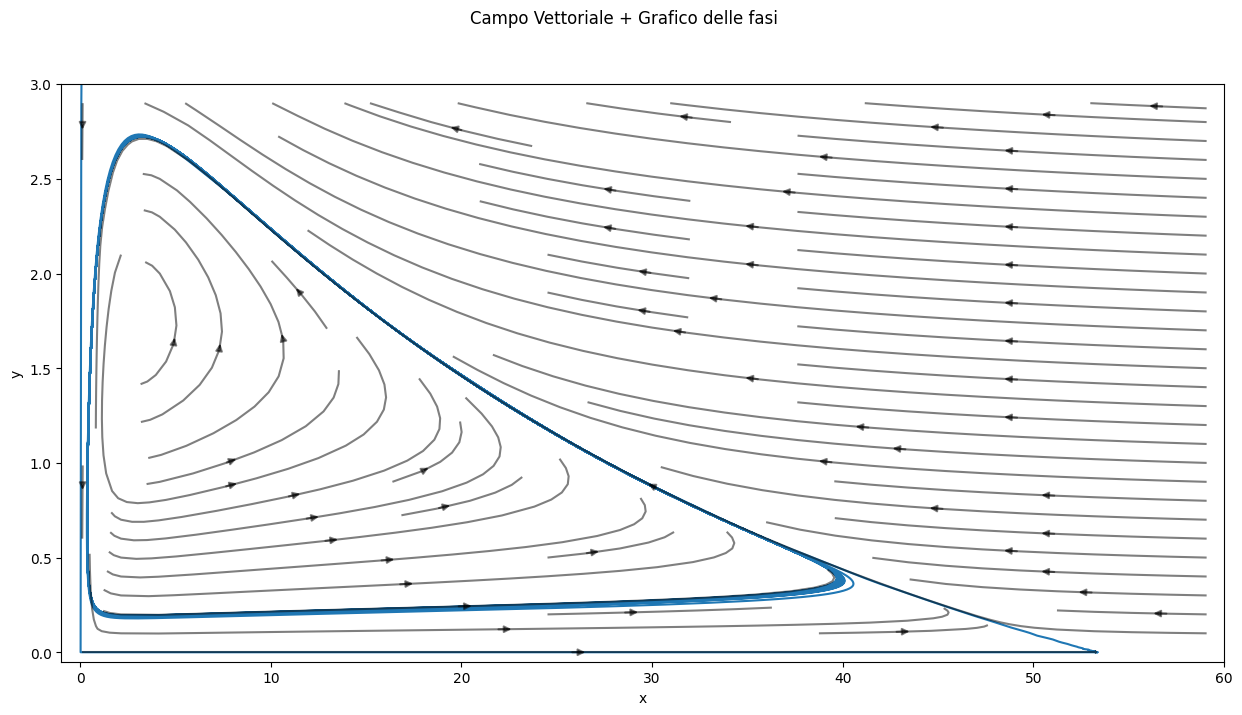

In [67]:
parameters = {
    'r': 2,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.5,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.4,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
}

simulate(5, 7, 1000, **parameters, name=f"xxx_0", solver='RK45')

fig, ax = plot_vector_field_alt(xlim = (0.1, 60), ylim = (0, 3), delta=(1, 0.1), density=1, transparency=0.5, **parameters)


fig.suptitle("Campo Vettoriale + Grafico delle fasi")
data = (np.loadtxt(f"./data/xxx_0.csv", delimiter=','))


ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid()
ax.plot(data[ :, 1], data[ :, 2], zorder=0)

ax.set_xlim(-1, 60)
ax.set_ylim(-0.05, 3)

plt.show()

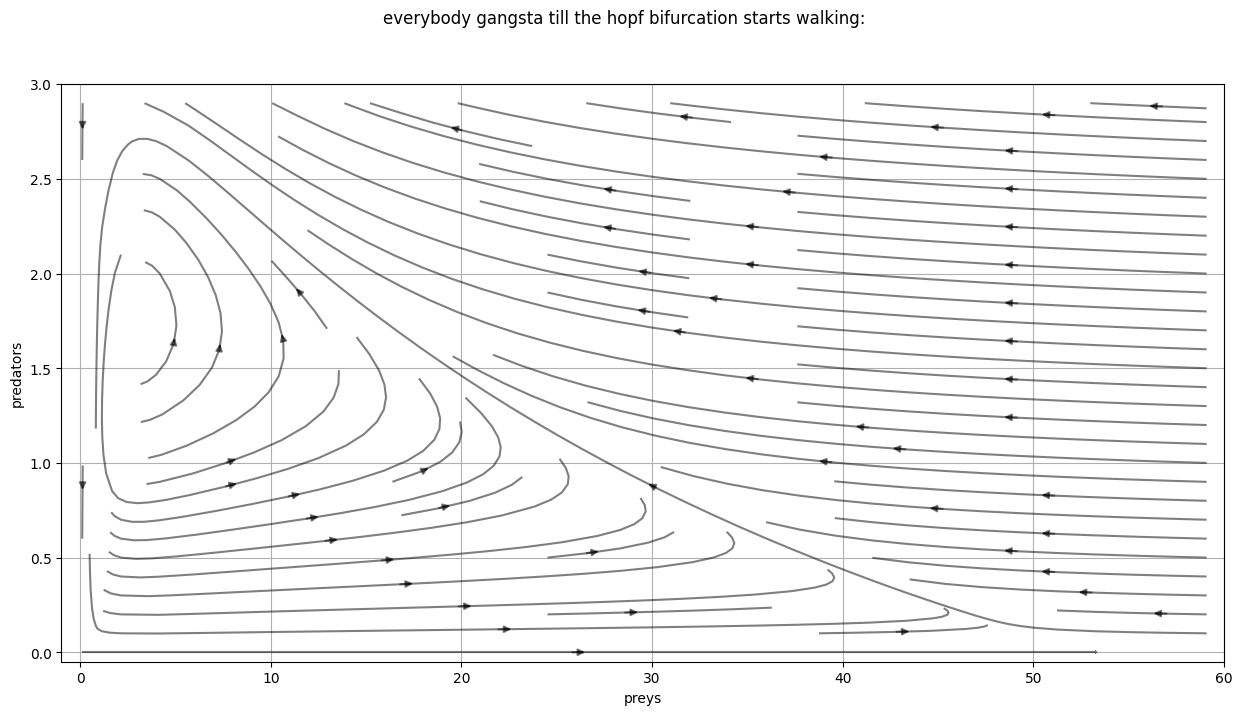

In [68]:
# animate the phase diagram
fig, ax = plot_vector_field_alt(xlim = (0.1, 60), ylim = (0, 3), delta=(1, 0.1), transparency=0.5, **parameters)

phase_curve, = ax.plot(data[0, 1], data[0, 2], 'r')
phase_dot, = ax.plot(data[0, 1], data[0, 2], 'r*')

fig.suptitle("everybody gangsta till the hopf bifurcation starts walking:")
ax.set_xlim(-1, 60)
ax.set_ylim(-0.05, 3)
ax.set_xlabel("preys")
ax.set_ylabel("predators")

k = 30

def animate(j):
    phase_curve.set_data(data[:j*k, 1], data[:j*k, 2])
    phase_dot.set_data([data[j*k, 1]], [data[j*k, 2]])

    return fig

ani = animation.FuncAnimation(fig, animate, frames=len(data[:, 0])//k)
ffmpeg_writer = animation.FFMpegWriter(fps=15)
ani.save('./videos/nulla di serio.mp4', writer=ffmpeg_writer)

### Ulteriore sperimentazione: modificare i fattori $\alpha \theta$ e $\sigma$

Studiamo il fattore $\alpha \theta$, che rappresenta la qualità/quantità del cibo aggiuntivo, modificandolo e osservando se esso va ad impattare la stabilità del modello in qualsiasi modo.

Senza perdere di generalità modifichiamo solo $\theta$, siccome si presenta *"sempre assieme"* con $\alpha$ e quindi alzare $\theta$ è *"equivalente"* ad abbassare $\alpha$.

Per osservare la variazione nella stabilità del modello, si disegna il diagramma di biforcazione.

#### $\alpha\theta$

In [76]:
parameters_base = {
    'r': 2,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.03,
    'm': 0.1,
    'alpha': 1,
    'a': 0.02,
    'd': 0.00002,
    'sigma': 0.5,
    'psi': 0.01,
}

from tqdm import tqdm

def draw_bifurc_theta(x0, y0, r, beta, e, k, eps, f, m, alpha, a, d, sigma, psi, theta_space):
    # punti d'equilibrio "costanti": W0 e W1, non dipendono da theta in nessun modo
    W0 = [(0, 0)]
    W1 = [((r-a)/k, 0)]

    W2 = [find_PIEP(r, beta, e, k, eps, f, m, alpha, theta_space[0], a, d, sigma, psi, init_solver=(x0, y0), silent=True)]

    equilibri = [ [W0[-1], W1[-1], W2[-1]] ]

    for theta in tqdm(theta_space[1:]):
        # trovo W3 usando il punto iniziale 
        if W2[-1] != (-1, -1):
            zero = find_PIEP(r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma, psi, init_solver=W2[-1], silent=True)

            if zero != -1:
                W2.append(zero)

            else:
                W2.append((-1, -1))
                
            equilibri.append([W0[-1], W1[-1], W2[-1]])

        else:
            equilibri.append([W0[-1], W1[-1], (-1, -1)])

    return np.array(equilibri)





In [77]:
logspace = np.logspace(-50, 3, 1000)

In [78]:
eqs = draw_bifurc_theta(50, 50, **parameters_base, theta_space=logspace)

100%|██████████| 999/999 [00:00<00:00, 19782.77it/s]


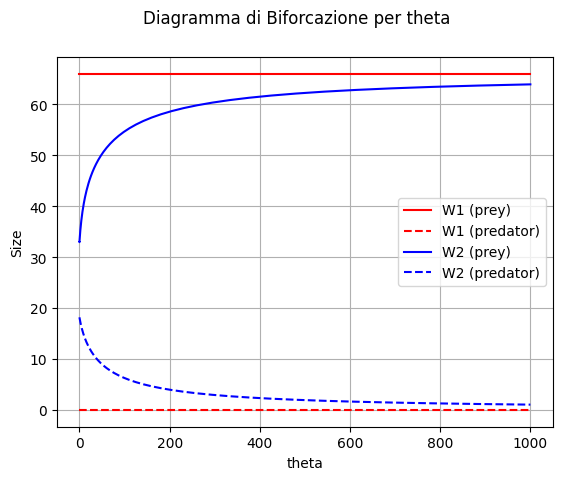

In [79]:
fig, ax = plt.subplots()

ax.plot(logspace, eqs[:, 1,0], label="W1 (prey)", color="r")
ax.plot(logspace, eqs[:, 1,1], label="W1 (predator)", color="r", linestyle="--")
ax.plot(logspace, eqs[:, 2,0], label="W2 (prey)", color="b")
ax.plot(logspace, eqs[:, 2,1], label="W2 (predator)", color="b", linestyle="--")

ax.set_xlabel("theta")
ax.set_ylabel("Size")

plt.suptitle("Diagramma di Biforcazione per theta")

ax.grid()

ax.legend()

plt.show()

Quindi all'aumentare del parametro $\alpha \theta$ in *ordini di grandezza di 10*, il punto d'equilibrio di coesistenza (W2) tende al punto d'equilibrio di assenza dei predatori.

Da un punto di vista modellistico ha senso, infatti aumentare $\alpha \theta$ vuol dire che *ci sono molte più risorse aggiuntive* e quindi i predatori tenderanno ad emigrare, riducendo la loro quantità.

#### $\sigma$
Facciamo una cosa analoga all'esperimento di prima, solo che facciamo variare $\sigma$ da $0$ in poi.

Aspettativa: fenomeno simile a sopra, ossia all'aumentare di $\sigma$ diminuiscono i predatori.

In [163]:
parameters_base = {
    'r': 2,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.03,
    'm': 0.1,
    'alpha': .00002,
    'a': 0.02,
    'd': 0.00002,
    'theta': 0.00002,
    'psi': 0.01,
}

from tqdm import tqdm

def draw_bifurc_sigma(x0, y0, r, beta, e, k, eps, f, m, alpha, a, d, theta, psi, sigma_space):
    # punti d'equilibrio "costanti": W0 e W1, non dipendono da theta in nessun modo
    W0 = [(0, 0)]
    W1 = [((r-a)/k, 0)]

    W2 = [find_PIEP(r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma_space[0], psi, init_solver=(x0, y0), silent=True)]

    equilibri = [ [W0[-1], W1[-1], W2[-1]] ]

    for sigma in tqdm(sigma_space[1:]):
        # trovo W3 usando il punto iniziale 
        if W2[-1] != (-1, -1):
            zero = find_PIEP(r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma, psi, init_solver=W2[-1], silent=True)

            if zero != -1:
                W2.append(zero)

            else:
                W2.append((-1, -1))
                
            equilibri.append([W0[-1], W1[-1], W2[-1]])

        else:
            equilibri.append([W0[-1], W1[-1], (-1, -1)])

    return np.array(equilibri)



100%|██████████| 99/99 [00:00<00:00, 12395.11it/s]

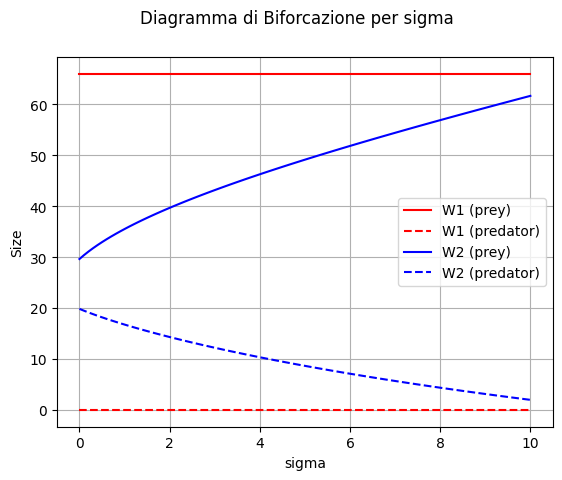

In [167]:
eqs = draw_bifurc_sigma(50, 50, **parameters_base, sigma_space=(sspace:=np.linspace(0, 10, 100)))

fig, ax = plt.subplots()

ax.plot(sspace, eqs[:, 1,0], label="W1 (prey)", color="r")
ax.plot(sspace, eqs[:, 1,1], label="W1 (predator)", color="r", linestyle="--")
ax.plot(sspace, eqs[:, 2,0], label="W2 (prey)", color="b")
ax.plot(sspace, eqs[:, 2,1], label="W2 (predator)", color="b", linestyle="--")

ax.set_xlabel("sigma")
ax.set_ylabel("Size")

plt.suptitle("Diagramma di Biforcazione per sigma")

ax.grid()

ax.legend()

plt.show()

In [104]:
parameters = {
    'r': 2,
    'beta': 0.5,
    'e': 0.4,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.03,
    'm': 0.1,
    'alpha': .00002,
    'a': 0.02,
    'd': 0.00002,
    'theta': 0.00002,
    'psi': 0.01,
}

simulate(10, 20, 50, **parameters, sigma=1, name="xd_0")
simulate(10, 20, 50, **parameters, sigma=5, name="xd_1")
simulate(10, 20, 50, **parameters, sigma=10, name="xd_2")
simulate(10, 20, 50, **parameters, sigma=15, name="xd_3")


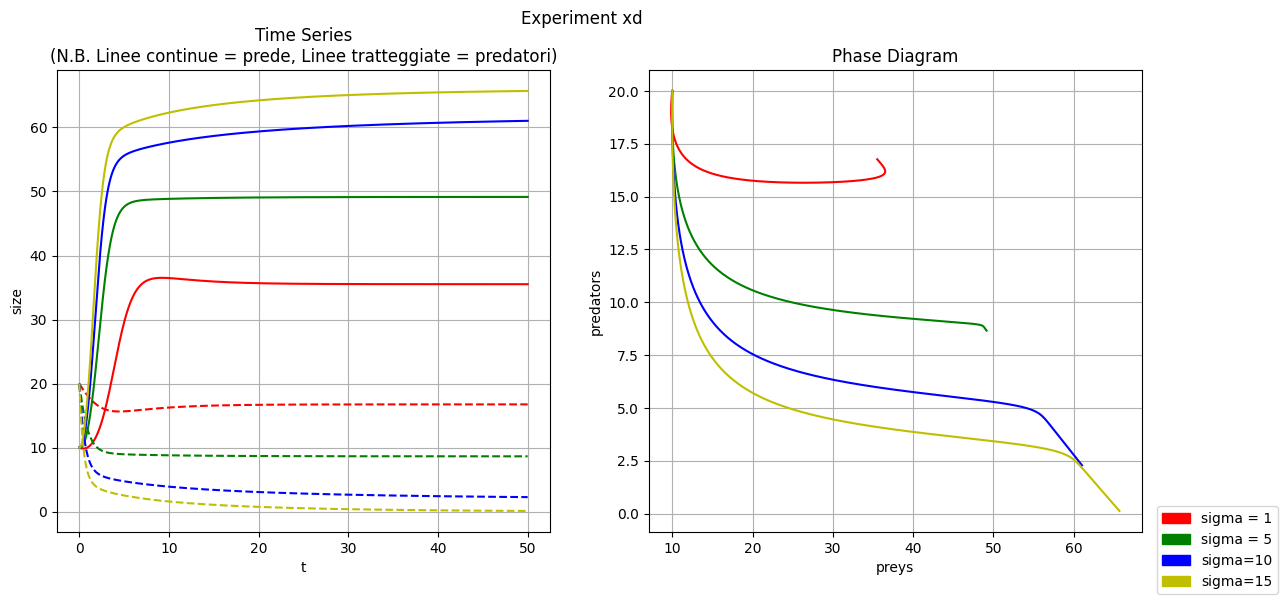

In [105]:
fig, axes = create_graphs('xd', 4, return_mode=True)

dict = {
    'r': 'sigma = 1',
    'g': 'sigma = 5',
    'b': 'sigma=10',
    'y': 'sigma=15'
}

patches = []

for col in dict:
    patches.append(matplotlib.patches.Patch(color=col, label=dict[col]))

fig.legend(handles=patches, loc='lower right')

plt.show()

### Ricondurre il modello ad altri modelli già noti

Notiamo che il nostro modello è una generalizzazione del modello di Rosenzweig-MacArthur. Infatti, presentano dinamiche simile per certe configurazioni di parametri (come cicli limite).

Infatti basta impostare i seguenti parametri, per ricondurci al modello di R-M adimensionalizzato:
- $f = 0$
- $r = 1$
- $m = 1-\eta$
- $\psi = 0$
- $e = C\rho$
- $\beta = \frac{1}{\eta}$ 
- $d= C$
- $\sigma = 0$
- $\varepsilon = 0$
- $a = 0$
- $k=1$

Con questi parametri otteniamo infatti

$$
\begin{align}
& \dot x = x\left( 1-\frac{y}{1+\eta x} - x\right) \\
&\dot y = Cy\left( \frac{\rho x}{1+\eta x}-1\right )
\end{align}
$$

6.0


c:\Users\ACER\anaconda3\Lib\site-packages\scipy\integrate\_ivp\ivp.py:621: UserWarning: The following arguments have no effect for a chosen solver: `solver`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


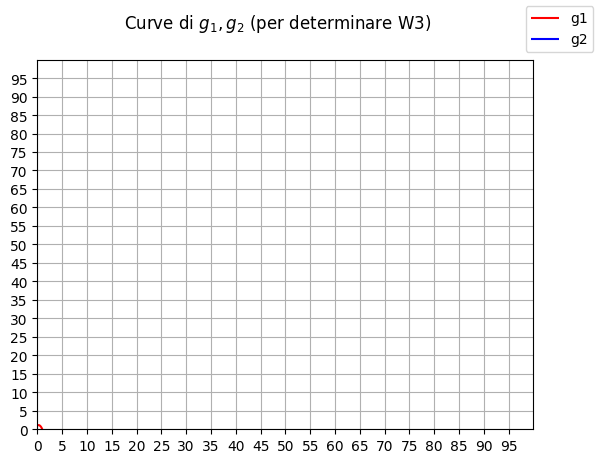

C:\Users\ACER\AppData\Local\Temp\ipykernel_13092\3977527584.py:39: RuntimeWarning: The number of calls to function has reached maxfev = 600.
  sol = fsolve(lambda vec: (g1(vec), g2(vec)), init_solver)


Punto d'equilibrio di coesistenza non esiste (soluzione trovata ha componente negativa)
N.B. Il punto d'equilibrio potrebbe esistere nonostante ciò, si consiglia di considerare a riutilizzare la funzione sfruttando il grafico prodotto sopra e inserendo in configurazione il punto iniziale del solver.
W1: (0, 0)
	LAS: False
W2: (1.0, 0)
	LAS: True
W3 non esiste


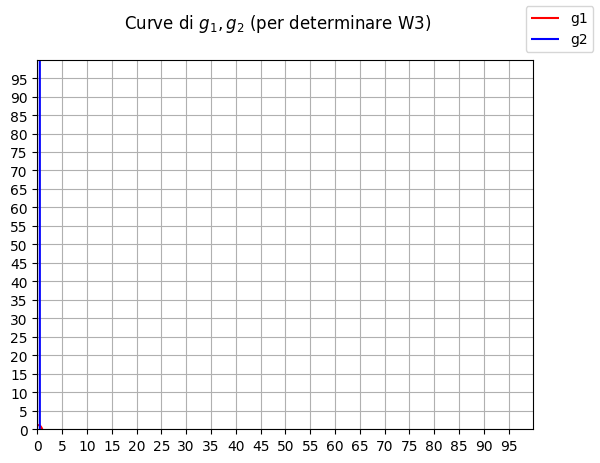

W2 (coesistenza positiva): x=0.5, y=1.0
W1: (0, 0)
	LAS: False
W2: (1.0, 0)
	LAS: False
W3: (0.5, 1.0)
	LAS: True


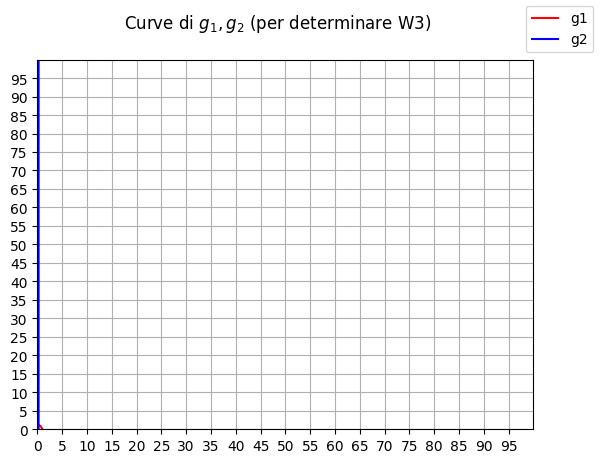

W2 (coesistenza positiva): x=0.24999999999772063, y=1.1250000000024853
W1: (0, 0)
	LAS: False
W2: (1.0, 0)
	LAS: False
W3: (0.24999999999772063, 1.1250000000024853)
	LAS: True


In [11]:
eta = 2
C = 0.75

print(eta * (eta+1)/(eta-1))

def generate_MR_params(rho, eta, C):
    return {
        'r': 1,
        'beta': 1/eta,
        'e': C*rho,
        'k': 1,
        'eps': 0,
        'f': 0,
        'm': 1-eta,
        'alpha': 1,
        'a': 0,
        'd': C,
        'theta': 1,
        'psi': 0,
        'sigma': 0
    }

rho_space = [2, 4, 6]

for i, rho in enumerate(rho_space):
    simulate(1,1, 100, **(params := generate_MR_params(rho, eta, C)), name=f"MR_{i}")
    check_stability_alt(**params, init_solver=(0.5, 0.5))

Text(0.5, 1.0, 'rho = 6')

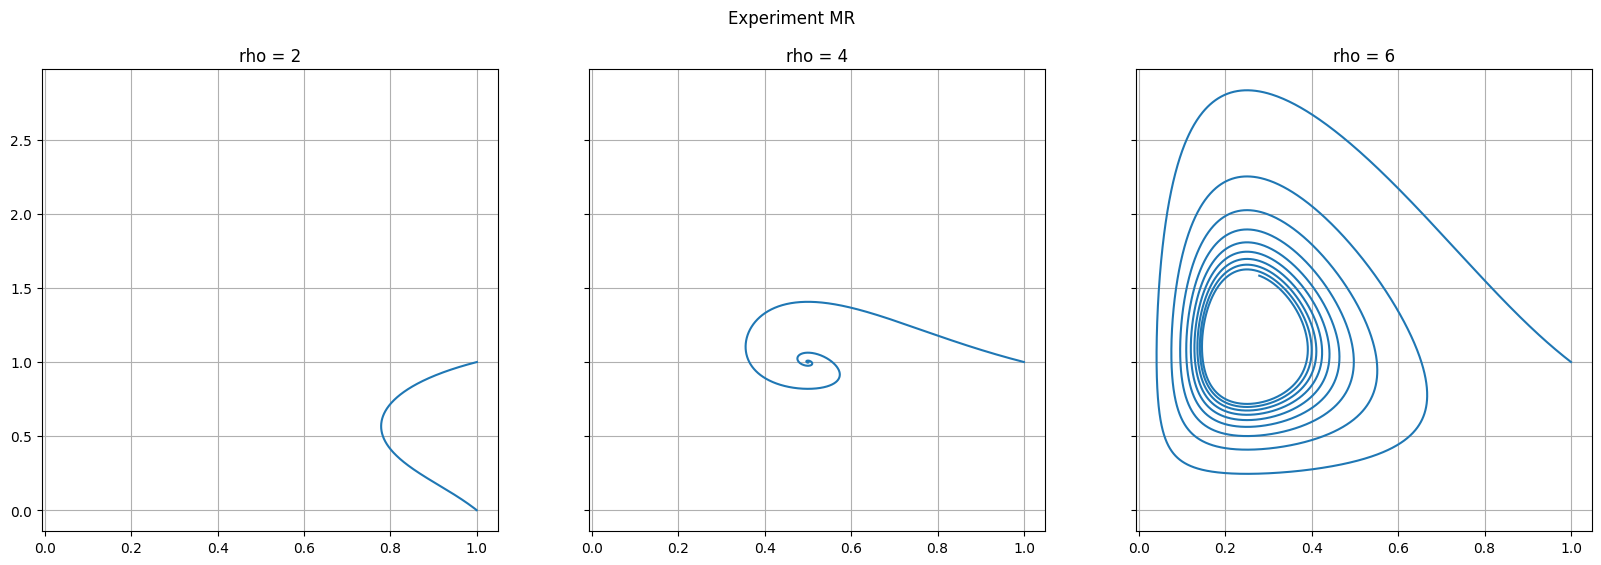

In [12]:
data = []

# carico dati salvati in file
for i in range(3):
    data.append(np.loadtxt(f"./data/MR_{i}.csv", delimiter=','))

# canvas
fig, axes = plt.subplots(1, 3, figsize = (20, 6), sharex=True, sharey=True)

fig.suptitle(f"Experiment MR")

for i in range(3):
    axes[i].grid(True)
    axes[i].plot(data[i][:, 1], data[i][:, 2])

ax1 = axes[0]
ax1.set_title("rho = 2")

ax2 = axes[1]
ax2.set_title("rho = 4")

ax3 = axes[2]
ax3.set_title("rho = 6")


E' MacArthur-Rosenzweig a tutti gli effetti!

Verificato usando il notebook del corso `C6 ROSEN.ipynb` usando gli identici parametri

### Periodicizzazione del Modello

Estratto: "Thecause of migration may be local climate, local availability of food, the season of the year, or mating"

**IDEA.** Rendere $\sigma = \sigma(t)$ una funzione periodica, come il seno.

Nel nostro caso definiremo la seguente famiglia di funzioni:

$$
\sigma_{A, \omega}(t):=A(\sin(\omega t)+1)
$$

(il +1 è necessario per rendere la funzione positiva)

In [132]:
# Definire il modello e robacce utili

def model_periodic(t, data, r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma_f, psi) -> Tuple[float, float]:
    # Calcola le derivate secondo il modello
    x = data[0]
    y = data[1]

    sigma = sigma_f(t)
    
    return (
        x * ( (r / (1+f*y)) - ((beta * (1-m) * y)/(psi*y + alpha*theta + (1-m)*x)) - a * (1+f*y) - k*x ),
        y * ( ((e * beta * (1-m)*x)/(psi*y + alpha*theta + (1-m)*x)) - d - (sigma / ((1-m)*x + alpha*theta)) - eps*y)
    )

def simulate_periodic(x0, y0, T, r, beta, e, k, eps, f, m, alpha, theta, a, d, sigma_f, psi, name: str, solver='RK45'):
    # Simula il modello e salvare i risultati in una cartella apposita
    
    timespan = (0, T)
    t_eval = np.linspace(0, T, int(10e3))
    
    sol = solve_ivp(model_periodic, timespan, (x0, y0), solver=solver, args = (r,beta,e,k,eps,f,m,alpha,theta,a,d,sigma_f,psi), t_eval = t_eval, rtol=1e-6, atol=1e-9)

    data = sol.y 

    X = data[0]
    Y = data[1]

    t = sol.t

    # Salvare i risultati in file (così da poter plottare in un secondo momento)
    np.savetxt(f"./data/{name}.csv", np.array([t, X,Y]).T, delimiter=",", header="t, x, y")


In [166]:
A = 3.5
omega=1

def sigma_sine1(t):
    return A*(np.sin(omega*t) + 1)

A2 = 3.5
omega2 = 2

def sigma_sine2(t):
    return A2*(np.sin(omega2*t) + 1)


A2 = 3.5
omega2 = 0.5

def sigma_sine3(t):
    return A2*(np.sin(omega2*t) + 1)

In [167]:

parameters = {
    'r': 2,
'beta': 0.5,
    'e': 1,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.03,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.02,
    'd': 0.00002,
    'sigma_f': sigma_sine1,
    'psi': 0.01,
}


parameters2 = {
    'r': 2,
'beta': 0.5,
    'e': 1,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.03,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.02,
    'd': 0.00002,
    'sigma_f': sigma_sine2,
    'psi': 0.01,
}

parameters3= {
    'r': 2,
'beta': 0.5,
    'e': 1,
    'k': 0.03,
    'eps': 0.01,
    'f': 0.03,
    'm': 0.1,
    'alpha': 0.00003,
    'theta': 0.00002,
    'a': 0.02,
    'd': 0.00002,
    'sigma_f': sigma_sine3,
    'psi': 0.01,
}


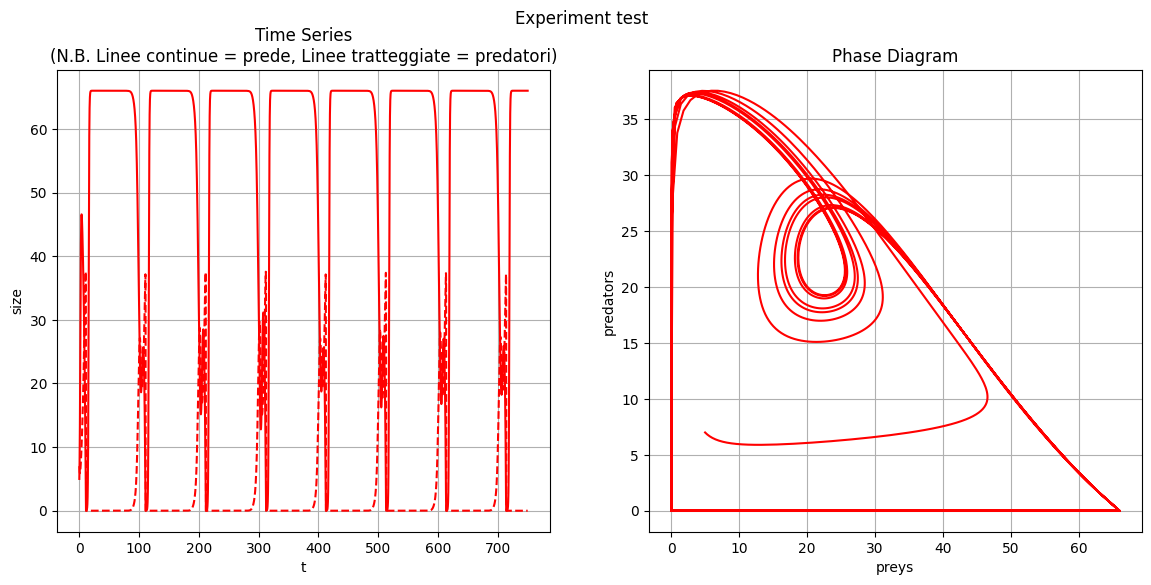

In [169]:
simulate_periodic(5, 7, 750, **parameters3, name="test_0")
create_graphs('test', 1)

plt.show()

In [ ]:
simulate_periodic(5, 7, 700, **parameters, name="CHAOS_0")
simulate_periodic(1,1, 700, **parameters, name="CHAOS_1")
simulate_periodic(20,20, 700, **parameters, name="CHAOS_2")


c:\Users\ACER\anaconda3\Lib\site-packages\scipy\integrate\_ivp\ivp.py:621: UserWarning: The following arguments have no effect for a chosen solver: `solver`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


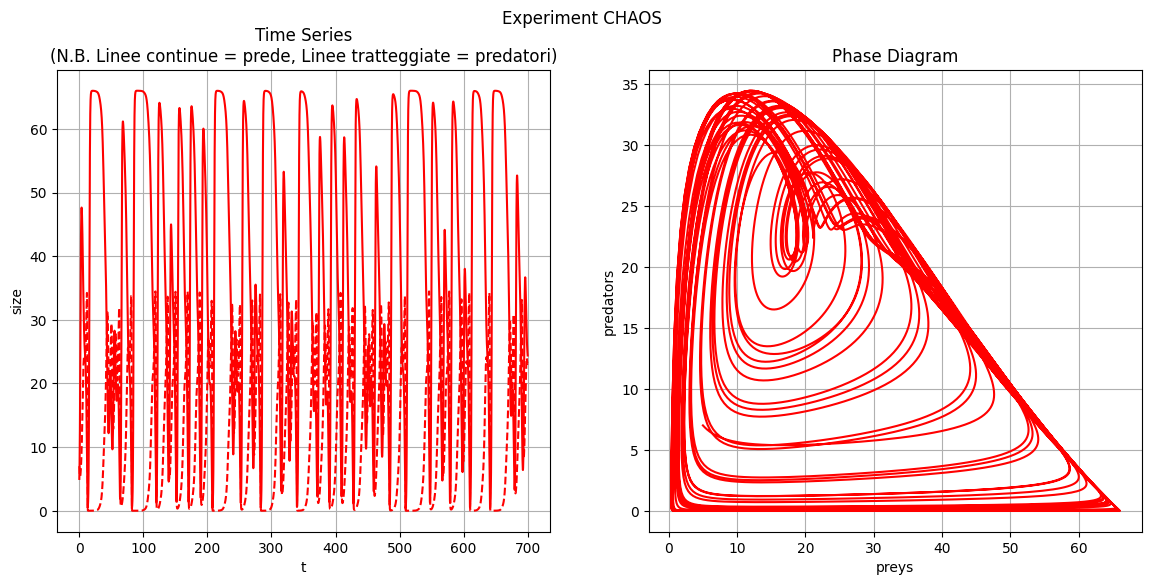

In [131]:
create_graphs('CHAOS', 1)

plt.show()

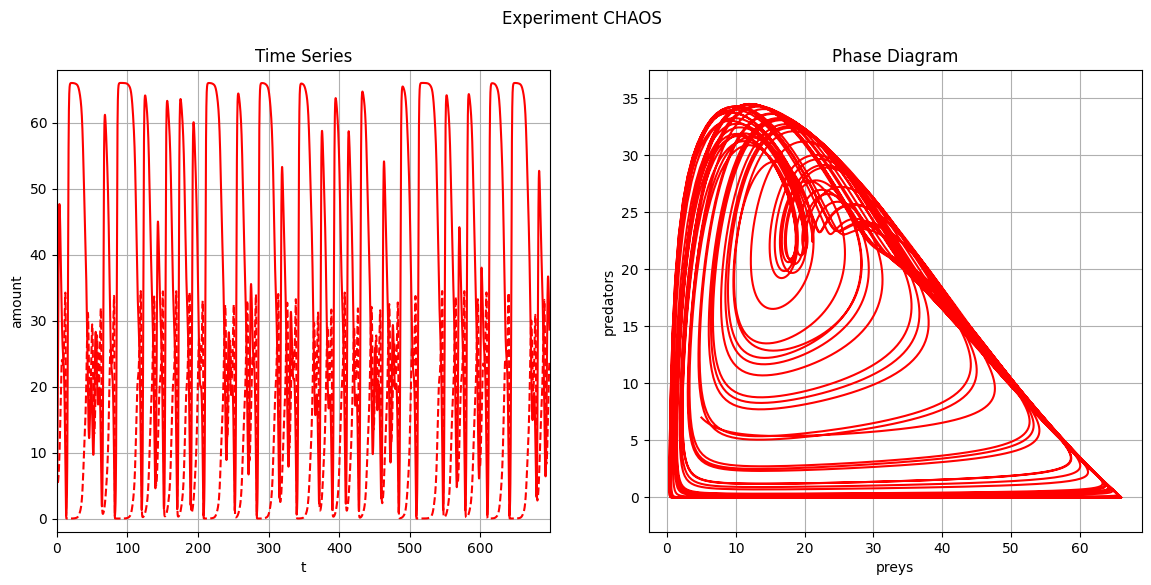

In [233]:
animate_plots('CHAOS', 1, multiplier=15)


In [ ]:
# animate time diagram
# animate the phase diagram

def animate_plots_alt(number: int, mult: int, add: int = 0, multiplier: int = 30):
    # creo grafici di un esperimento
    # number: numero dell'esperimento
    # mult: di solito gli esperimenti coinvolgono più simulazioni simultanee, quindi dire quanti sono le simulazioni...
    # add: serve solo se voglio prendere una parte specifica dell'esperimento
    # multiplier: serve per rendere il rendering più veloce, ossia skippare alcuni dati (sennò il mio pc ci mette decenni...)

    # alt perché nel diagramma delle fasi rendo la "trail" delle "particelle" moolto trasparente
    
    data = []

    # carico dati salvati in file
    for i in range(mult):
        try:
            data.append(np.loadtxt(f"./data/{number}_{i}.csv", delimiter=','))
        except:
            raise Exception("Parametri in configurazione invalidi!!!")
            

    data = np.array(data)

    fig, axes = plt.subplots(1, 2, figsize=(14,6))
    fig.suptitle(f"Experiment {number}")


    # time series
    ax1 = axes[0]
    ax2 = axes[1]

    prey_curves = []
    predator_curves = []

    markers = ['r', 'b', 'y', 'g', 'k']

    for i in range(add, mult):
        prey_curves.append(ax1.plot(data[i][0, 0], data[i][0, 1], markers[i]))
        predator_curves.append(ax1.plot(data[i][0, 0], data[i][0, 2], f"{markers[i]}--"))

    ax1.set_title(f"Time Series")
    ax1.grid()
    ax1.set_xlabel("t")
    ax1.set_ylabel("amount")

    ax1.set_xlim(0, data[0, -1, 0] - 1)
    ax1.set_ylim(np.min(data[:, :, [1,2]]) - 2, np.max(data[:, :, [1,2]]) + 2)

    phase_curves = []
    phase_dots = []

    dots = ['ro', 'bo', 'yo', 'go', 'ko']

    for i in range(add, mult):
        phase_curves.append(ax2.plot(data[i][0, 1], data[i][0, 2], markers[i], alpha=0.1))
        phase_dots.append(ax2.plot(data[i][0, 1], data[i][0, 2], dots[i]))

    ax2.set_title(f"Phase Diagram")
    ax2.grid()
    ax2.set_xlabel("preys")
    ax2.set_ylabel("predators")

    ax2.set_xlim(np.min(data[:, :, [1]]) - 3, np.max(data[:, :, [1]]) + 3)
    ax2.set_ylim(np.min(data[:, :, [2]]) - 3, np.max(data[:, :, [2]]) + 3) # tutti questi -1, +1 per rendere più visibile gli estremi


    def animate(j):
        for i in range(mult-add):
            prey = prey_curves[i][0]
            predator = predator_curves[i][0]

            prey.set_data(data[i][:j*multiplier, 0], data[i][:j*multiplier, 1])
            predator.set_data(data[i][:j*multiplier, 0], data[i][:j*multiplier, 2])

        for i in range(mult-add):
            phase_curve = phase_curves[i][0]
            phase_dot = phase_dots[i][0]

            phase_curve.set_data(data[i][:j*multiplier, 1], data[i][:j*multiplier, 2])
            phase_dot.set_data([data[i][j*multiplier, 1]], [data[i][j*multiplier, 2]])

        return fig

    ani = animation.FuncAnimation(fig, animate, frames=len(data[i][:, 0])//multiplier)
    ffmpeg_writer = animation.FFMpegWriter(fps=30)
    ani.save(f'./videos/{number}_{add}.mp4', writer=ffmpeg_writer)

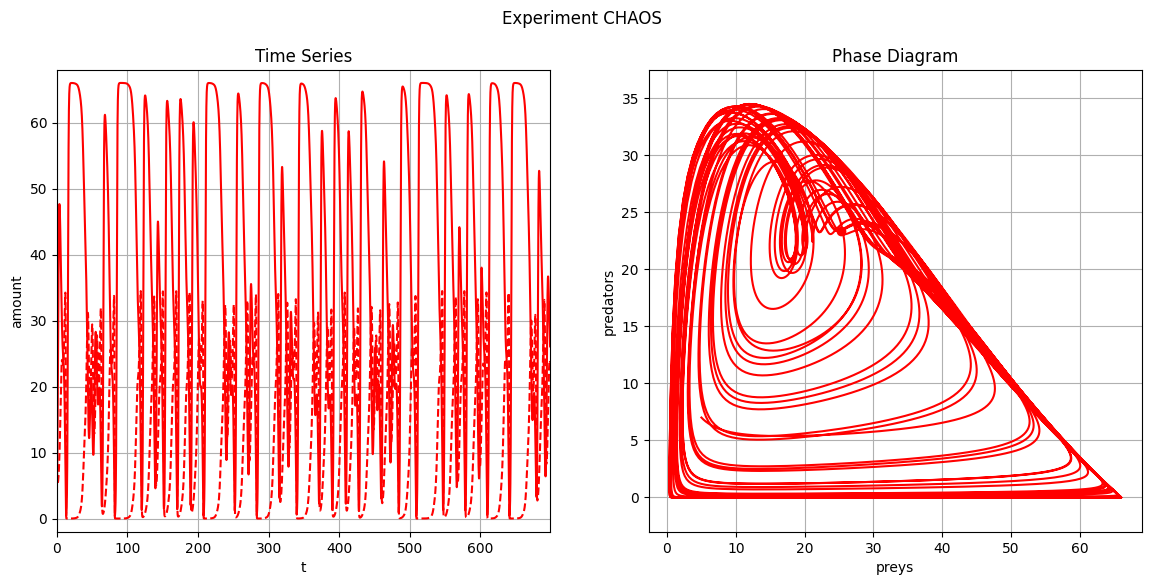

In [269]:
animate_plots('CHAOS', 1, multiplier=10)

In [257]:
simulate_periodic(7, 0.025, 500, **parameters2, name="BUTTERFLY_0")
simulate_periodic(7, 0.5, 500, **parameters2, name="BUTTERFLY_1")
simulate_periodic(7, 1, 500, **parameters2, name="BUTTERFLY_2")

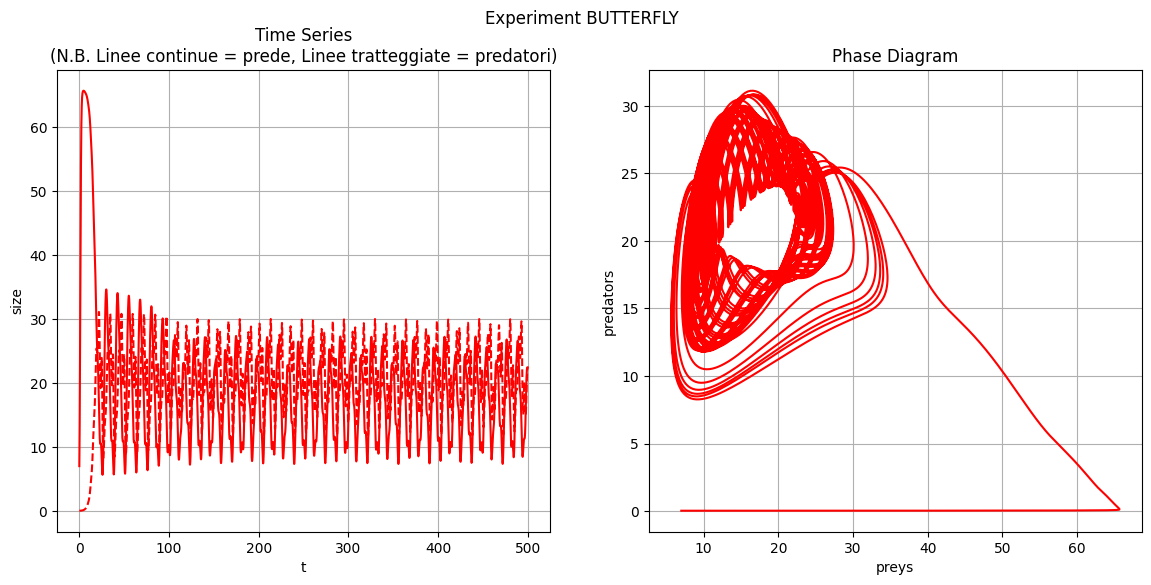

In [258]:
create_graphs('BUTTERFLY', 1)

plt.show()

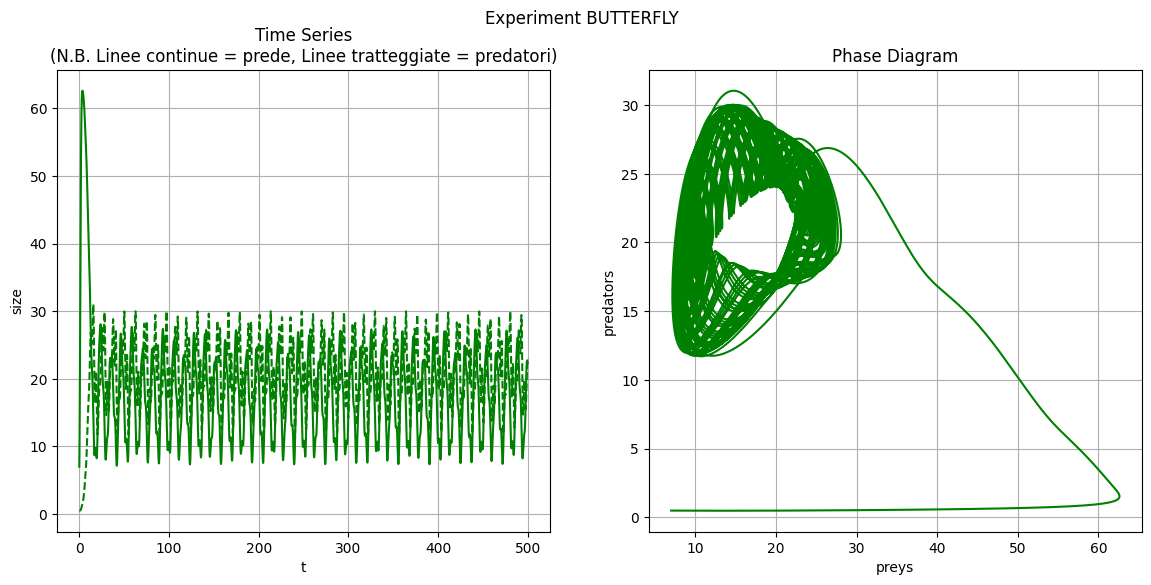

In [259]:
create_graphs('BUTTERFLY', 2, 1)

plt.show()

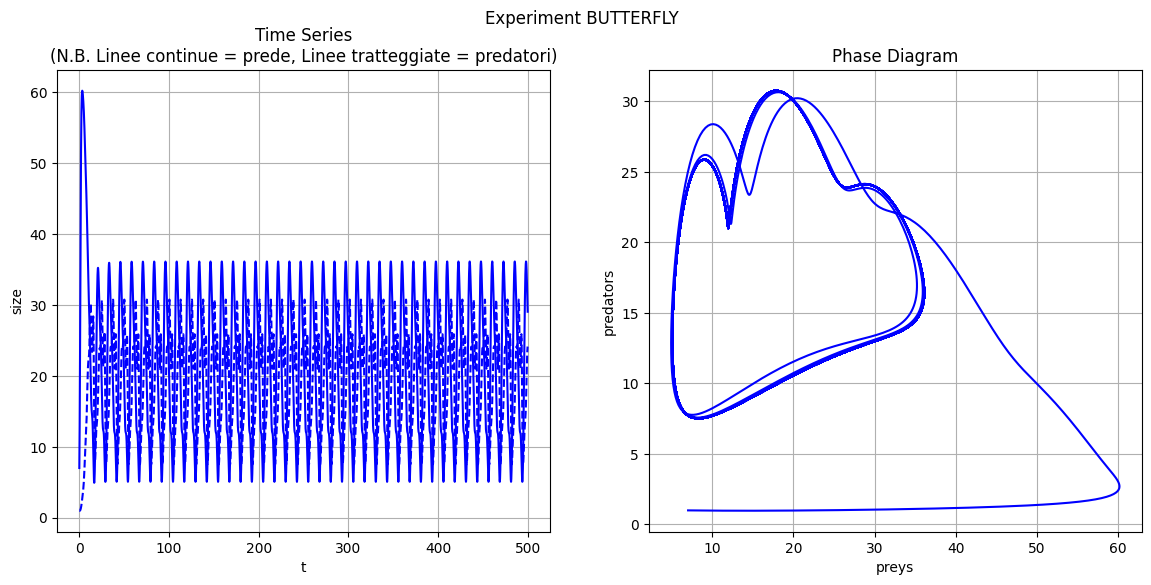

In [260]:
create_graphs('BUTTERFLY', 3, 2)

plt.show()

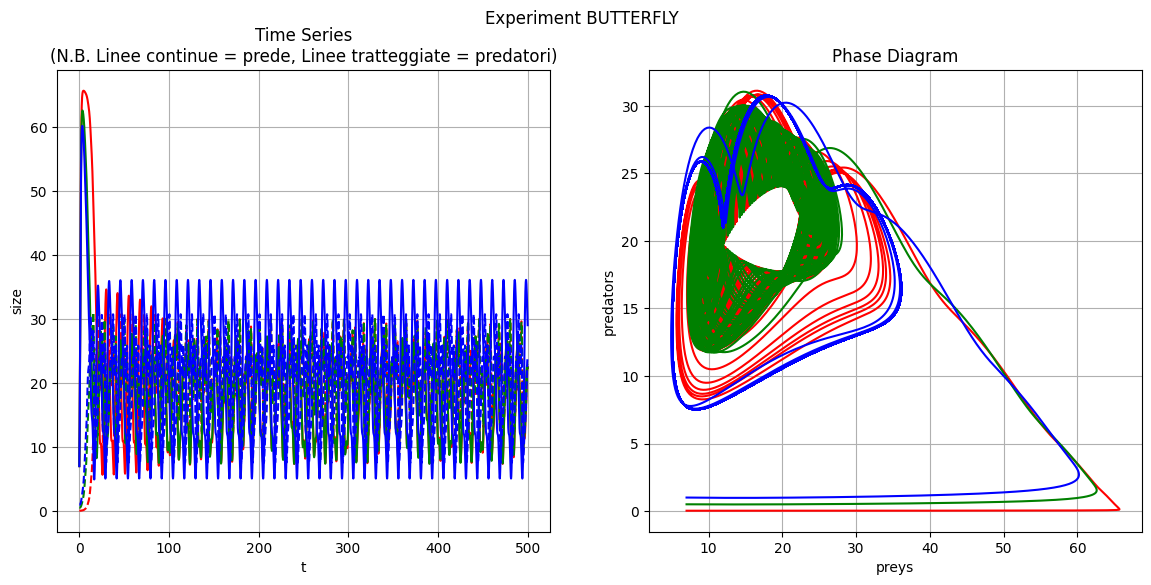

In [261]:
create_graphs('BUTTERFLY', 3)

plt.show()

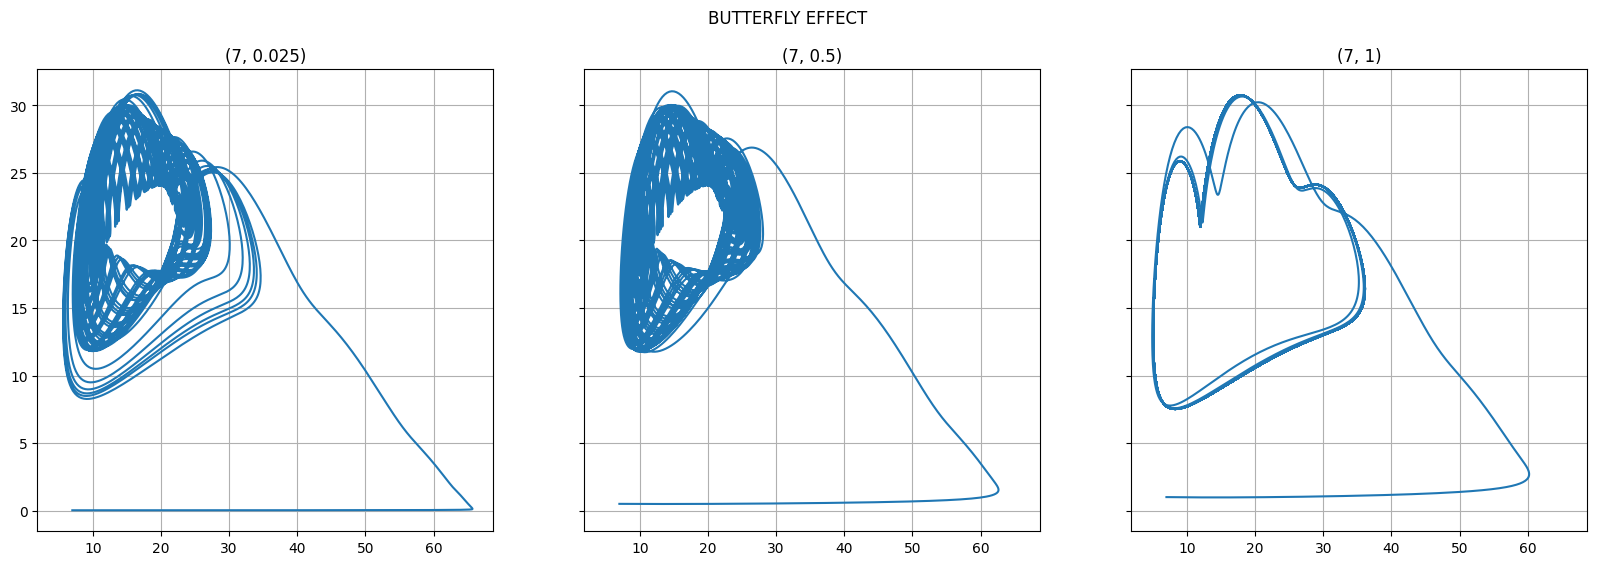

In [262]:
data = []

# carico dati salvati in file
for i in range(3):
    data.append(np.loadtxt(f"./data/BUTTERFLY_{i}.csv", delimiter=','))

# canvas
fig, axes = plt.subplots(1, 3, figsize = (20, 6), sharex=True, sharey=True)

fig.suptitle(f"BUTTERFLY EFFECT")

for i in range(3):
    axes[i].grid(True)
    axes[i].plot(data[i][:, 1], data[i][:, 2])

ax1 = axes[0]
ax1.set_title("(7, 0.025)")

ax2 = axes[1]
ax2.set_title("(7, 0.5)")

ax3 = axes[2]
ax3.set_title("(7, 1)")

plt.show()

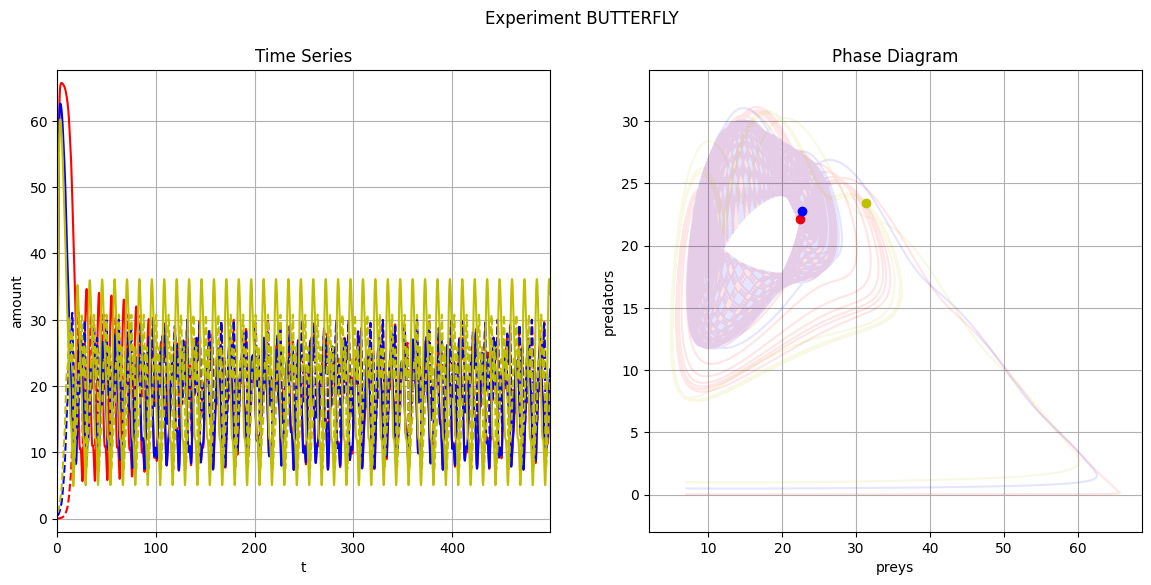

In [250]:
animate_plots_alt('BUTTERFLY', 3, multiplier=10)


Penultima cosa: variare della frequenza

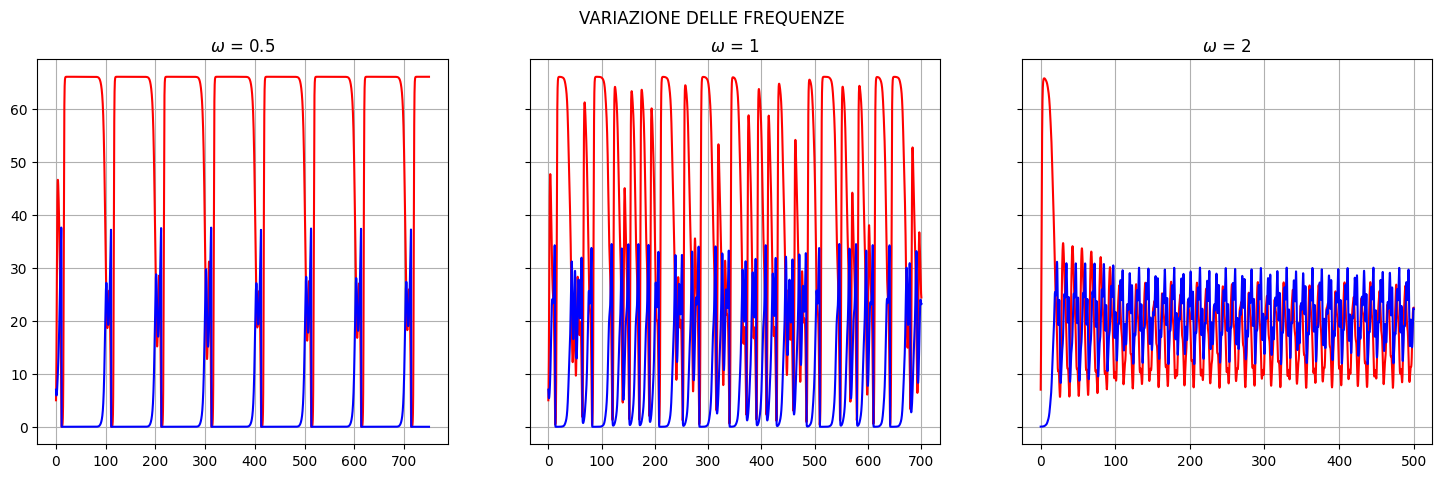

In [178]:
data = []

# carico dati salvati in file
data.append(np.loadtxt(f"./data/test_0.csv", delimiter=','))
data.append(np.loadtxt(f"./data/CHAOS_0.csv", delimiter=','))
data.append(np.loadtxt(f"./data/BUTTERFLY_0.csv", delimiter=','))

# canvas
fig, axes = plt.subplots(1, 3, figsize = (18, 5), sharex=False, sharey=True)

fig.suptitle(f"VARIAZIONE DELLE FREQUENZE")

for i in range(3):
    axes[i].grid(True)

    axes[i].plot(data[i][ :, 0], data[i][ :, 1], 'r')
    axes[i].plot(data[i][ :, 0], data[i][ :, 2], 'b')

ax1 = axes[0]
ax1.set_title(r"$\omega$ = 0.5")

ax2 = axes[1]
ax2.set_title(r"$\omega$ = 1")

ax3 = axes[2]
ax3.set_title(r"$\omega$ = 2")

plt.show()

Osserviamo che il modello è caotico per un "intervallo" di $\omega$; se è invece troppo piccola o troppo grande, rimane non-caotica ma periodica

Analizziamo le proprietà statistiche del modello caotico

In [77]:
import seaborn as sns
import pandas as pd 

data = (np.loadtxt(f"./data/CHAOS_0.csv", delimiter=','))


df = pd.DataFrame(data[100:, :])
df.columns = ['T', 'preys', 'predators']

print("General Overview")
print(df[['preys', 'predators']].describe())

print()

print("Skewness")
print(df[['preys', 'predators']].skew())

print()

print("Kurtosis")
print(df[['preys', 'predators']].kurtosis())


General Overview
             preys    predators
count  9900.000000  9900.000000
mean     39.023226    11.703542
std      21.619743    11.285159
min       0.345421     0.000086
25%      19.695127     0.514433
50%      39.380980     8.431203
75%      61.884173    22.396668
max      65.996900    34.461062

Skewness
preys       -0.163278
predators    0.444615
dtype: float64

Kurtosis
preys       -1.409434
predators   -1.302299
dtype: float64


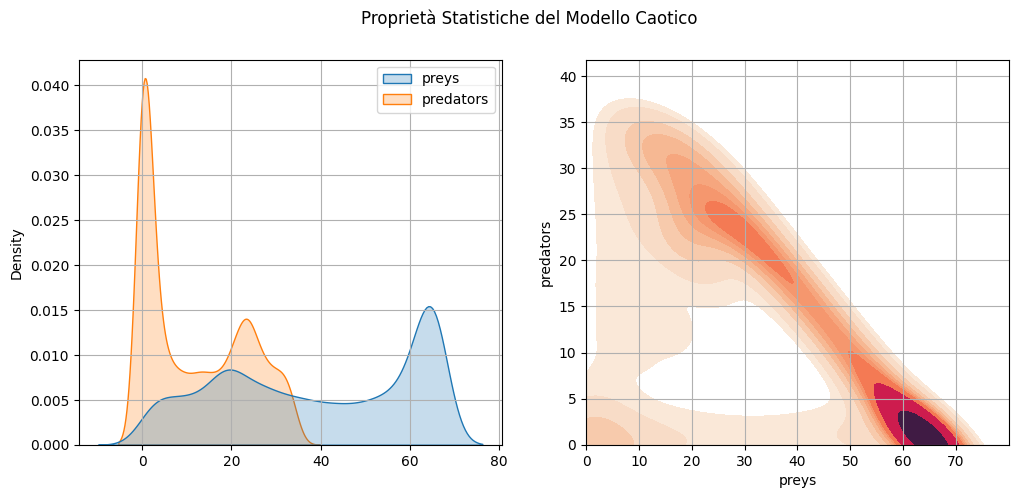

In [99]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle("Proprietà Statistiche del Modello Caotico")
axes[0].grid(True)
axes[1].grid(True)

sns.kdeplot(df.iloc[:, [1,2]], fill=True, ax=axes[0])
sns.kdeplot(df.iloc[:, [1,2]], x='preys', y = 'predators', cmap='rocket_r', fill=True, ax=axes[1], clip=(0, 100), levels=10)

plt.show()

Come possiamo vedere, il modello si comporta come un distribuzione statistica (sebbene moolto strana, infatti presenta grandi assimetrie)

Fine del progetto. $\blacksquare$

# Dichiarazioni e riferimenti

* Dichiaro che l'intero progetto è stato svolto in maniera completamente autonoma
* In particolare, non è stato usato nessun LLM per scrivere codice
* Alcune parti del codice sono ispirati a script esterni:
    * Implementazione del modello e simulazioni: vari notebook del corso 
    * Animazione dei grafici: script di un tutorial online, il file in riferimento è [questo](./animate_simple_pendulum.ipynb).
    * Varie consultazioni sul web, tra cui documentazioni officiali e StackOverFlow